<a href="https://colab.research.google.com/github/arreseb/Estrutura-de-dados/blob/main/aposentadoria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MODELAGEM PREDITIVA DE APOSENTADORIA**
### **Disciplina: Machine Learning**
**Grupo 4**
- Francisca Trajano
- Halisson de Lima Souza
- Marcelo Beserra
- Ricardo Pasquali
- Vitor Poubel

Data: 07 de julho de 2026

**Objetivos**

Construir modelos de Machine Learning capazes de identificar padrões associados aos indivíduos aposentados utilizando técnicas de classificação.


## **Capítulo 1**
### **Parte 1 - Introdução e Preparação do Ambiente**

Importando bibliotecas

In [93]:
# ==============================================================================
# 1. IMPORTAÇÃO DAS BIBLIOTECAS
# ==============================================================================

# ------------------------------------------------------------------------------
# Manipulação de dados
# ------------------------------------------------------------------------------

import pandas as pd
import numpy as np

# ------------------------------------------------------------------------------
# Visualização gráfica
# ------------------------------------------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------------------------
# Configuração dos gráficos
# ------------------------------------------------------------------------------

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (12,6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

# ------------------------------------------------------------------------------
# Configuração do pandas
# ------------------------------------------------------------------------------

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# ------------------------------------------------------------------------------
# Ignorar mensagens de aviso
# ------------------------------------------------------------------------------

import warnings
warnings.filterwarnings("ignore")

print("="*90)
print("AMBIENTE CONFIGURADO COM SUCESSO")
print("="*90)


AMBIENTE CONFIGURADO COM SUCESSO


Carregando o dataset (aposentadoria_v1.xlsx) para o collab:

**Faça o upload para o google collab antes de executar esta célula.**

In [92]:
arquivo = "/content/aposentadoria_v1.xlsx"

df = pd.read_excel(arquivo)

print("\nBase carregada com sucesso do arquivo local!\n")


Base carregada com sucesso do arquivo local!



In [94]:
# ==============================================================================
# 3. VISUALIZAÇÃO INICIAL
# ==============================================================================

print("="*90)
print("PRIMEIROS REGISTROS")
print("="*90)

display(df.head())


print("="*90)
print("ÚLTIMOS REGISTROS")
print("="*90)

display(df.tail())



PRIMEIROS REGISTROS


,Idade,Sexo,EstadoCivil,AnosEstudo,RendaAnual,CoberturaPrevidenciaria,CondicoesSaude,SaudeAutoavaliada,Tabagismo,HorasTrabalhadas,TamanhoFamilia,aposentado
0,52,Feminino,Casado,8,75232,1,3,Ruim,Fumante,36,4,1
1,73,Feminino,Divorciado,17,85860,1,2,Boa,Ex-fumante,39,2,0
2,70,Masculino,Divorciado,18,62156,1,2,Boa,Nunca,19,5,1
3,63,Masculino,Casado,13,117061,1,6,Ruim,Ex-fumante,34,4,1
4,63,Masculino,Casado,16,116966,1,2,Regular,Ex-fumante,37,3,1


ÚLTIMOS REGISTROS


,Idade,Sexo,EstadoCivil,AnosEstudo,RendaAnual,CoberturaPrevidenciaria,CondicoesSaude,SaudeAutoavaliada,Tabagismo,HorasTrabalhadas,TamanhoFamilia,aposentado
4995,56,Feminino,Casado,15,90358,1,0,Excelente,Ex-fumante,41,1,0
4996,73,Masculino,Casado,11,92732,0,6,Ruim,Fumante,50,6,1
4997,75,Feminino,Casado,17,108565,1,3,Ruim,Nunca,42,6,1
4998,71,Masculino,Casado,12,117898,1,6,Ruim,Nunca,11,3,1
4999,65,Masculino,Viúvo,12,105446,0,4,Ruim,Ex-fumante,49,2,1


In [6]:
# ==============================================================================
# 4. DIMENSÃO DO DATASET
# ==============================================================================

print("="*90)
print("DIMENSÃO DA BASE")
print("="*90)

linhas = df.shape[0]
colunas = df.shape[1]

print(f"Quantidade de registros : {linhas}")
print(f"Quantidade de variáveis : {colunas}")


DIMENSÃO DA BASE
Quantidade de registros : 5000
Quantidade de variáveis : 12


In [7]:
# ==============================================================================
# 5. LISTA DAS VARIÁVEIS
# ==============================================================================

print("="*90)
print("VARIÁVEIS DA BASE")
print("="*90)

for numero, coluna in enumerate(df.columns, start=1):

    print(f"{numero:02d} - {coluna}")



VARIÁVEIS DA BASE
01 - Idade
02 - Sexo
03 - EstadoCivil
04 - AnosEstudo
05 - RendaAnual
06 - CoberturaPrevidenciaria
07 - CondicoesSaude
08 - SaudeAutoavaliada
09 - Tabagismo
10 - HorasTrabalhadas
11 - TamanhoFamilia
12 - aposentado


In [8]:
# ==============================================================================
# 6. DICIONÁRIO DAS VARIÁVEIS
# ==============================================================================

dicionario = pd.DataFrame({

    "Variável":[

        "Idade",
        "Sexo",
        "EstadoCivil",
        "AnosEstudo",
        "RendaAnual",
        "CoberturaPrevidenciaria",
        "CondicoesSaude",
        "SaudeAutoavaliada",
        "Tabagismo",
        "HorasTrabalhadas",
        "TamanhoFamilia",
        "aposentado"

    ],

    "Descrição":[

        "Idade do indivíduo em anos",

        "Sexo biológico",

        "Estado civil",

        "Anos de escolaridade",

        "Renda anual",

        "Possui cobertura previdenciária",

        "Quantidade de condições de saúde",

        "Percepção do estado de saúde",

        "Situação quanto ao tabagismo",

        "Carga horária semanal",

        "Número de pessoas da família",

        "Variável alvo"

    ],

    "Tipo Esperado":[

        "Numérica",

        "Categórica",

        "Categórica",

        "Numérica",

        "Numérica",

        "Binária",

        "Ordinal",

        "Ordinal",

        "Categórica",

        "Numérica",

        "Numérica",

        "Binária"

    ]

})

print("="*90)
print("DICIONÁRIO DOS DADOS")
print("="*90)

display(dicionario)



DICIONÁRIO DOS DADOS


,Variável,Descrição,Tipo Esperado
0,Idade,Idade do indivíduo em anos,Numérica
1,Sexo,Sexo biológico,Categórica
2,EstadoCivil,Estado civil,Categórica
3,AnosEstudo,Anos de escolaridade,Numérica
4,RendaAnual,Renda anual,Numérica
5,CoberturaPrevidenciaria,Possui cobertura previdenciária,Binária
6,CondicoesSaude,Quantidade de condições de saúde,Ordinal
7,SaudeAutoavaliada,Percepção do estado de saúde,Ordinal
8,Tabagismo,Situação quanto ao tabagismo,Categórica
9,HorasTrabalhadas,Carga horária semanal,Numérica


In [9]:
# ==============================================================================
# 7. TIPOS DAS VARIÁVEIS
# ==============================================================================

print("="*90)
print("TIPOS IDENTIFICADOS PELO PYTHON")
print("="*90)

display(df.dtypes)


TIPOS IDENTIFICADOS PELO PYTHON


,0
Idade,int64
Sexo,object
EstadoCivil,object
AnosEstudo,int64
RendaAnual,int64
CoberturaPrevidenciaria,int64
CondicoesSaude,int64
SaudeAutoavaliada,object
Tabagismo,object
HorasTrabalhadas,int64


In [10]:
# ==============================================================================
# 8. ESTRUTURA GERAL DA BASE
# ==============================================================================

print("="*90)
print("INFORMAÇÕES GERAIS")
print("="*90)

df.info()



INFORMAÇÕES GERAIS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Idade                    5000 non-null   int64 
 1   Sexo                     5000 non-null   object
 2   EstadoCivil              5000 non-null   object
 3   AnosEstudo               5000 non-null   int64 
 4   RendaAnual               5000 non-null   int64 
 5   CoberturaPrevidenciaria  5000 non-null   int64 
 6   CondicoesSaude           5000 non-null   int64 
 7   SaudeAutoavaliada        5000 non-null   object
 8   Tabagismo                5000 non-null   object
 9   HorasTrabalhadas         5000 non-null   int64 
 10  TamanhoFamilia           5000 non-null   int64 
 11  aposentado               5000 non-null   int64 
dtypes: int64(8), object(4)
memory usage: 468.9+ KB


In [11]:
# ==============================================================================
# 9. IDENTIFICAÇÃO DAS VARIÁVEIS NUMÉRICAS
# ==============================================================================

numericas = df.select_dtypes(

    include=["int64","float64"]

).columns.tolist()

print("="*90)
print("VARIÁVEIS NUMÉRICAS")
print("="*90)

for coluna in numericas:

    print(coluna)



VARIÁVEIS NUMÉRICAS
Idade
AnosEstudo
RendaAnual
CoberturaPrevidenciaria
CondicoesSaude
HorasTrabalhadas
TamanhoFamilia
aposentado


In [12]:
# ==============================================================================
# 10. IDENTIFICAÇÃO DAS VARIÁVEIS CATEGÓRICAS
# ==============================================================================

categoricas = df.select_dtypes(

    include=["object","category"]

).columns.tolist()

print("="*90)
print("VARIÁVEIS CATEGÓRICAS")
print("="*90)

for coluna in categoricas:

    print(coluna)



VARIÁVEIS CATEGÓRICAS
Sexo
EstadoCivil
SaudeAutoavaliada
Tabagismo


In [13]:
# ==============================================================================
# 11. MEMÓRIA UTILIZADA
# ==============================================================================

print("="*90)
print("CONSUMO DE MEMÓRIA")
print("="*90)

memoria = df.memory_usage(deep=True).sum() / 1024**2

print(f"Memória utilizada: {memoria:.2f} MB")



CONSUMO DE MEMÓRIA
Memória utilizada: 1.40 MB


In [14]:
# ==============================================================================
# 12. CÓPIA DE SEGURANÇA DA BASE
# ==============================================================================

df_original = df.copy()

print("="*90)
print("BACKUP DA BASE CRIADO")
print("="*90)



BACKUP DA BASE CRIADO


In [15]:
# ==============================================================================
# 13. RESUMO DO CAPÍTULO
# ==============================================================================

print("="*90)
print("CAPÍTULO 1 - ETAPA 1 CONCLUÍDA")
print("="*90)

print("""
✓ Ambiente configurado

✓ Bibliotecas carregadas

✓ Base importada

✓ Estrutura identificada

✓ Dicionário criado

✓ Variáveis identificadas

✓ Tipos verificados

✓ Base pronta para análise de qualidade
""")

CAPÍTULO 1 - ETAPA 1 CONCLUÍDA

✓ Ambiente configurado

✓ Bibliotecas carregadas

✓ Base importada

✓ Estrutura identificada

✓ Dicionário criado

✓ Variáveis identificadas

✓ Tipos verificados

✓ Base pronta para análise de qualidade



## **Capítulo 1**
#### **Parte 2 - Análise da Qualidade dos Dados**

In [16]:
# ==============================================================================
# 14. VALORES AUSENTES
# ==============================================================================

print("\nVERIFICANDO VALORES AUSENTES...\n")

valores_nulos = df.isnull().sum()

percentual_nulos = round((valores_nulos / len(df)) * 100,2)

tabela_nulos = pd.DataFrame({

    "Valores Nulos": valores_nulos,

    "Percentual (%)": percentual_nulos

})

display(tabela_nulos)

print(f"\nTotal de valores ausentes: {valores_nulos.sum()}")




VERIFICANDO VALORES AUSENTES...



,Valores Nulos,Percentual (%)
Idade,0,0.0
Sexo,0,0.0
EstadoCivil,0,0.0
AnosEstudo,0,0.0
RendaAnual,0,0.0
CoberturaPrevidenciaria,0,0.0
CondicoesSaude,0,0.0
SaudeAutoavaliada,0,0.0
Tabagismo,0,0.0
HorasTrabalhadas,0,0.0



Total de valores ausentes: 0


In [17]:
# ==============================================================================
# 15. REGISTROS DUPLICADOS
# ==============================================================================

print("\nVERIFICANDO DUPLICIDADES...\n")

duplicados = df.duplicated().sum()

print(f"Registros duplicados encontrados: {duplicados}")




VERIFICANDO DUPLICIDADES...

Registros duplicados encontrados: 0


In [18]:
# ==============================================================================
# 16. ESTATÍSTICAS DESCRITIVAS
# ==============================================================================

print("="*90)
print("ESTATÍSTICAS DAS VARIÁVEIS NUMÉRICAS")
print("="*90)

display(df.describe().T)


ESTATÍSTICAS DAS VARIÁVEIS NUMÉRICAS


,count,mean,std,min,25%,50%,75%,max
Idade,5000.0,64.9524,8.967777,50.0,57.00,65.0,73.0,80.0
AnosEstudo,5000.0,13.9680,2.899355,8.0,12.00,14.0,16.0,20.0
RendaAnual,5000.0,87342.2244,24221.443386,20000.0,69233.25,87252.0,104575.0,150000.0
CoberturaPrevidenciaria,5000.0,0.6138,0.486926,0.0,0.00,1.0,1.0,1.0
CondicoesSaude,5000.0,1.7078,1.415069,0.0,1.00,1.0,3.0,6.0
HorasTrabalhadas,5000.0,33.4060,10.396672,0.0,26.00,33.0,40.0,60.0
TamanhoFamilia,5000.0,3.5430,1.695856,1.0,2.00,4.0,5.0,6.0
aposentado,5000.0,0.5658,0.495701,0.0,0.00,1.0,1.0,1.0


In [19]:
# ==============================================================================
# 17. ESTATÍSTICAS DAS VARIÁVEIS CATEGÓRICAS
# ==============================================================================

print("="*90)
print("ESTATÍSTICAS DAS VARIÁVEIS CATEGÓRICAS")
print("="*90)

display(df.describe(include="object").T)



ESTATÍSTICAS DAS VARIÁVEIS CATEGÓRICAS


,count,unique,top,freq
Sexo,5000,2,Feminino,2531
EstadoCivil,5000,4,Casado,2260
SaudeAutoavaliada,5000,4,Excelente,1865
Tabagismo,5000,3,Nunca,1948


In [20]:
# ==============================================================================
# 18. DISTRIBUIÇÃO DA VARIÁVEL ALVO
# ==============================================================================

print("="*90)
print("DISTRIBUIÇÃO DA VARIÁVEL APOSENTADO")
print("="*90)

frequencia = df["aposentado"].value_counts().sort_index()

percentual = round(
    df["aposentado"].value_counts(normalize=True).sort_index()*100,
    2
)

tabela_alvo = pd.DataFrame({

    "Quantidade": frequencia,

    "Percentual (%)": percentual

})

display(tabela_alvo)



DISTRIBUIÇÃO DA VARIÁVEL APOSENTADO


,Quantidade,Percentual (%)
aposentado,,
0,2171,43.42
1,2829,56.58


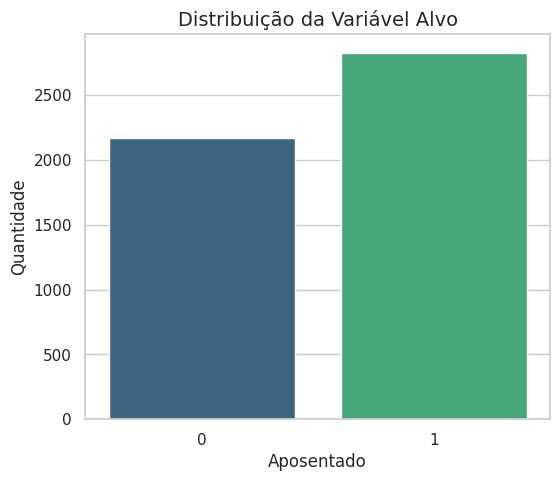

In [21]:
# ==============================================================================
# 19. GRÁFICO DA VARIÁVEL ALVO
# ==============================================================================

plt.figure(figsize=(6,5))

sns.countplot(

    data=df,

    x="aposentado",

    palette="viridis"

)

plt.title("Distribuição da Variável Alvo")

plt.xlabel("Aposentado")

plt.ylabel("Quantidade")

plt.show()



In [ ]:
# ==============================================================================
# 20. FREQUÊNCIA DAS VARIÁVEIS CATEGÓRICAS
# ==============================================================================

categoricas = [

    "Sexo",

    "EstadoCivil",

    "SaudeAutoavaliada",

    "Tabagismo"

]

for coluna in categoricas:

    print("="*80)

    print(coluna.upper())

    print("="*80)

    display(

        df[coluna].value_counts()

    )



SEXO


,count
Sexo,
Feminino,2531
Masculino,2469


ESTADOCIVIL


,count
EstadoCivil,
Casado,2260
Solteiro,970
Viúvo,900
Divorciado,870


SAUDEAUTOAVALIADA


,count
SaudeAutoavaliada,
Excelente,1865
Boa,1614
Regular,1018
Ruim,503


TABAGISMO


,count
Tabagismo,
Nunca,1948
Ex-fumante,1746
Fumante,1306


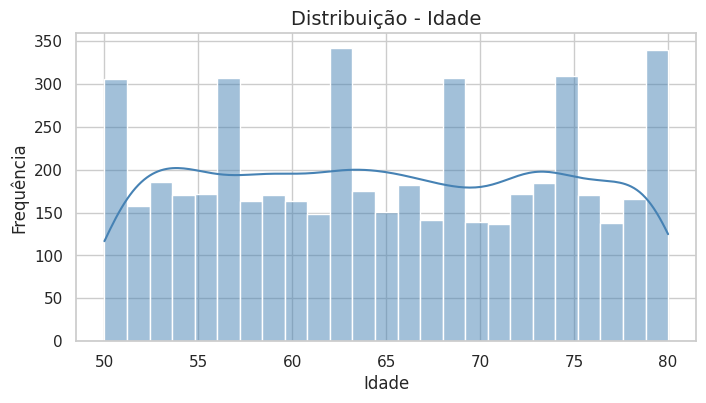

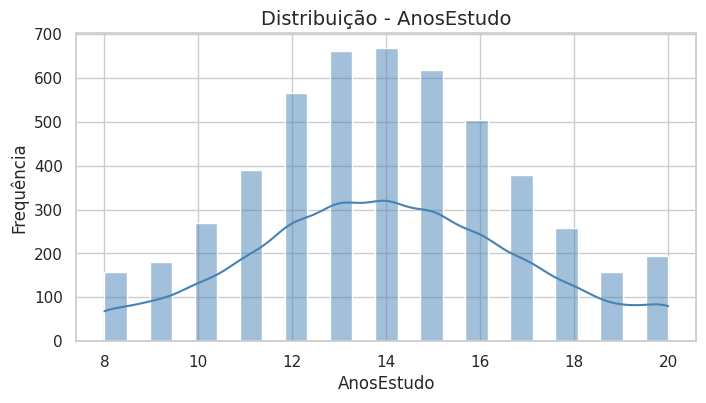

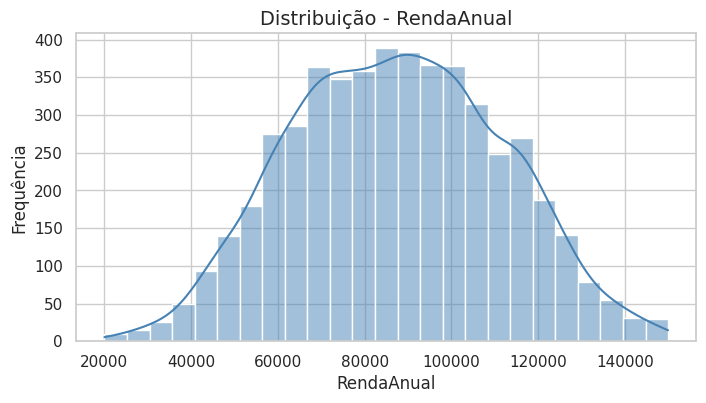

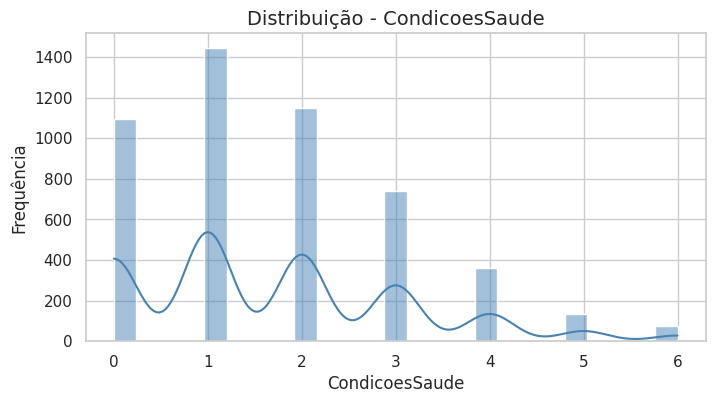

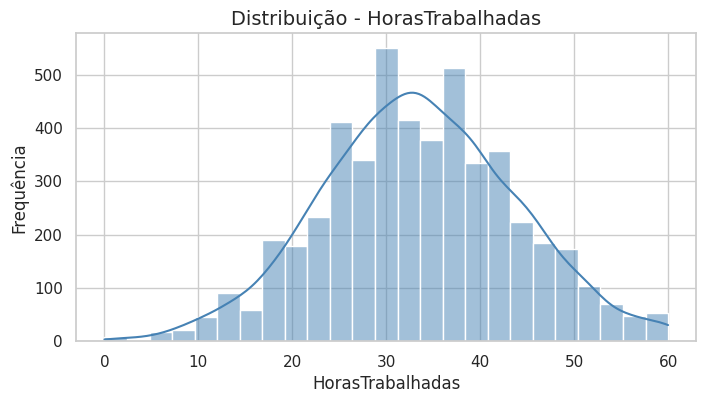

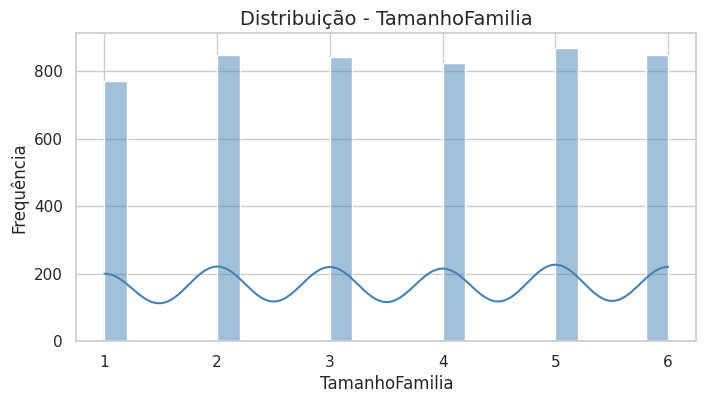

In [ ]:
# ==============================================================================
# 21. DISTRIBUIÇÃO DAS VARIÁVEIS NUMÉRICAS
# ==============================================================================

numericas = [

    "Idade",

    "AnosEstudo",

    "RendaAnual",

    "CondicoesSaude",

    "HorasTrabalhadas",

    "TamanhoFamilia"

]

for coluna in numericas:

    plt.figure(figsize=(8,4))

    sns.histplot(

        data=df,

        x=coluna,

        bins=25,

        kde=True,

        color="steelblue"

    )

    plt.title(f"Distribuição - {coluna}")

    plt.xlabel(coluna)

    plt.ylabel("Frequência")

    plt.show()



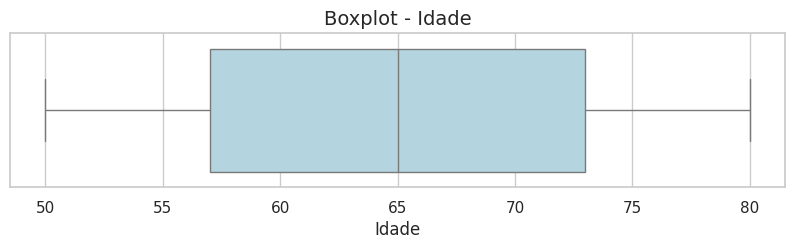

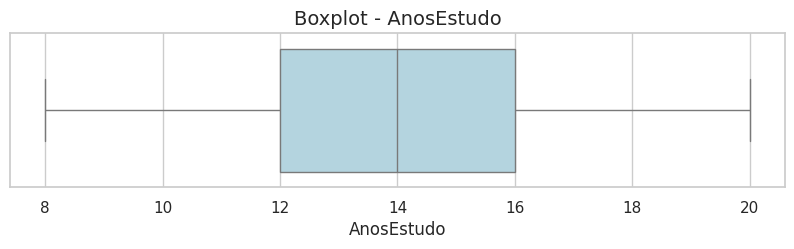

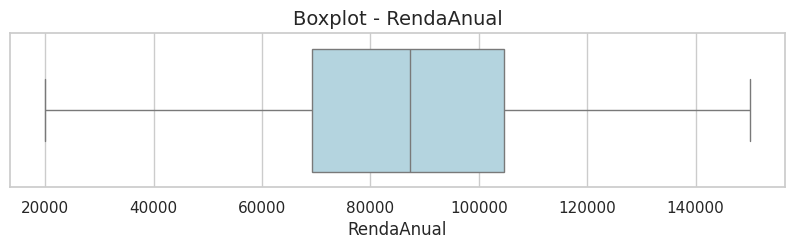

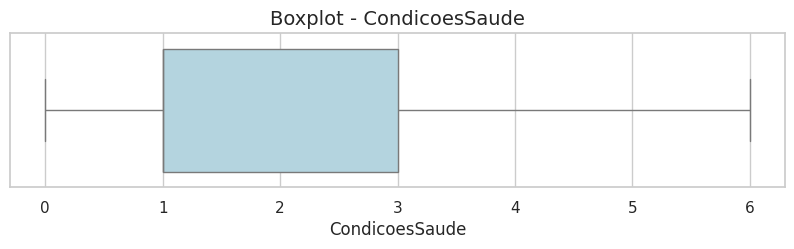

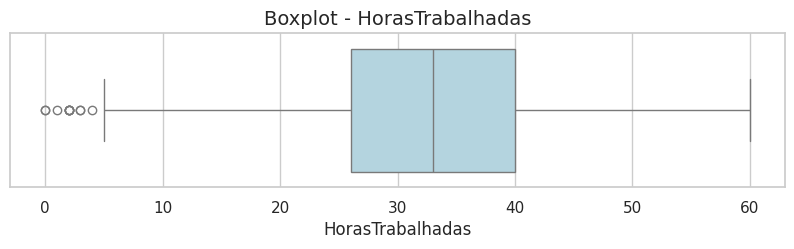

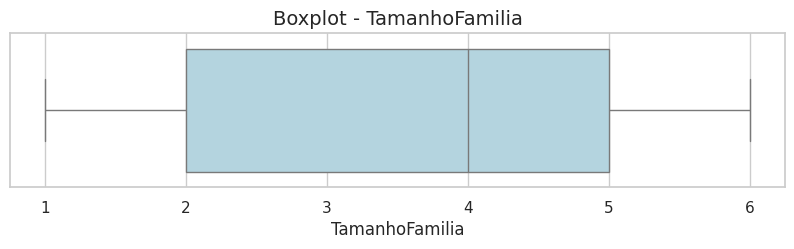

In [ ]:
# ==============================================================================
# 22. BOXPLOTS
# ==============================================================================

for coluna in numericas:

    plt.figure(figsize=(10,2))

    sns.boxplot(

        x=df[coluna],

        color="lightblue"

    )

    plt.title(f"Boxplot - {coluna}")

    plt.show()



In [ ]:
# ==============================================================================
# 23. IDENTIFICAÇÃO DE POSSÍVEIS OUTLIERS
# ==============================================================================

print("="*90)
print("IDENTIFICAÇÃO DE OUTLIERS PELO MÉTODO IQR")
print("="*90)

for coluna in numericas:

    Q1 = df[coluna].quantile(0.25)

    Q3 = df[coluna].quantile(0.75)

    IQR = Q3 - Q1

    inferior = Q1 - 1.5 * IQR

    superior = Q3 + 1.5 * IQR

    quantidade = df[
        (df[coluna] < inferior) |
        (df[coluna] > superior)
    ].shape[0]

    print(f"{coluna:<25}: {quantidade} possíveis outliers")



IDENTIFICAÇÃO DE OUTLIERS PELO MÉTODO IQR
Idade                    : 0 possíveis outliers
AnosEstudo               : 0 possíveis outliers
RendaAnual               : 0 possíveis outliers
CondicoesSaude           : 0 possíveis outliers
HorasTrabalhadas         : 11 possíveis outliers
TamanhoFamilia           : 0 possíveis outliers


In [22]:
# ==============================================================================
# 24. RESUMO DA VARIÁVEL ALVO
# ==============================================================================

print("="*90)
print("RESUMO DA VARIÁVEL ALVO")
print("="*90)

print(f"Quantidade de aposentados     : {df['aposentado'].sum()}")

print(f"Quantidade de não aposentados : {(df['aposentado']==0).sum()}")


RESUMO DA VARIÁVEL ALVO
Quantidade de aposentados     : 2829
Quantidade de não aposentados : 2171


In [23]:
# ==============================================================================
# 25. RESUMO DA ETAPA
# ==============================================================================

print("="*90)
print("ANÁLISE DA QUALIDADE DOS DADOS FINALIZADA")
print("="*90)

print("""

✓ Valores ausentes verificados

✓ Registros duplicados verificados

✓ Estatísticas descritivas geradas

✓ Distribuições analisadas

✓ Variáveis categóricas analisadas

✓ Variáveis numéricas analisadas

✓ Boxplots construídos

✓ Possíveis outliers identificados

✓ Variável alvo analisada

Base pronta para Análise Exploratória (EDA).

""")

ANÁLISE DA QUALIDADE DOS DADOS FINALIZADA


✓ Valores ausentes verificados

✓ Registros duplicados verificados

✓ Estatísticas descritivas geradas

✓ Distribuições analisadas

✓ Variáveis categóricas analisadas

✓ Variáveis numéricas analisadas

✓ Boxplots construídos

✓ Possíveis outliers identificados

✓ Variável alvo analisada

Base pronta para Análise Exploratória (EDA).




## **Capítulo 1**
### **Parte 3 - Análise Exploratória dos Dados (EDA)**

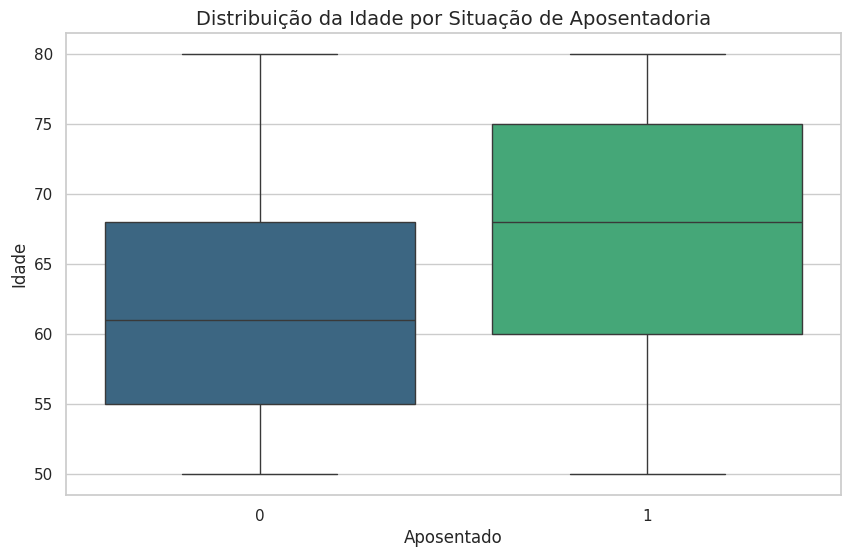

In [ ]:
# ==============================================================================
# 26. IDADE x APOSENTADORIA
# ==============================================================================

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="aposentado",
    y="Idade",
    palette="viridis"
)

plt.title("Distribuição da Idade por Situação de Aposentadoria")

plt.xlabel("Aposentado")

plt.ylabel("Idade")

plt.show()



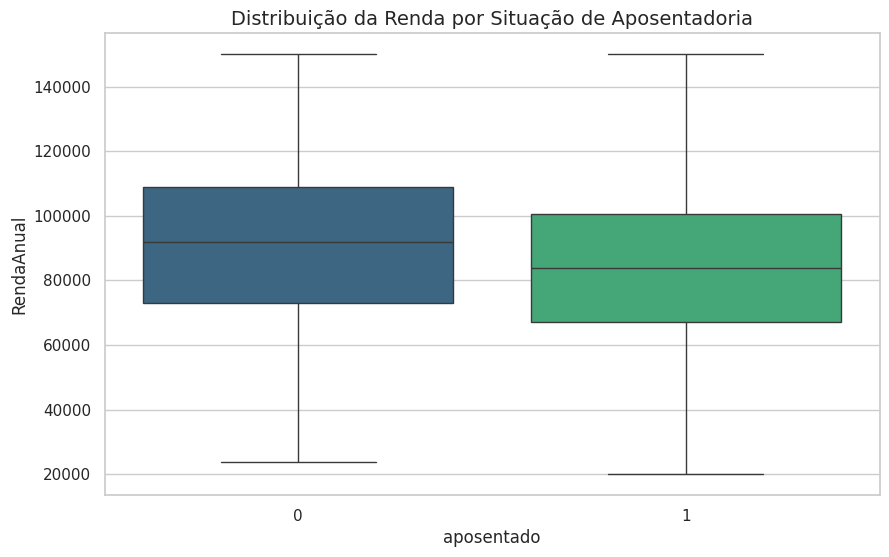

In [ ]:
# ==============================================================================
# 27. RENDA x APOSENTADORIA
# ==============================================================================

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="aposentado",
    y="RendaAnual",
    palette="viridis"
)

plt.title("Distribuição da Renda por Situação de Aposentadoria")

plt.show()



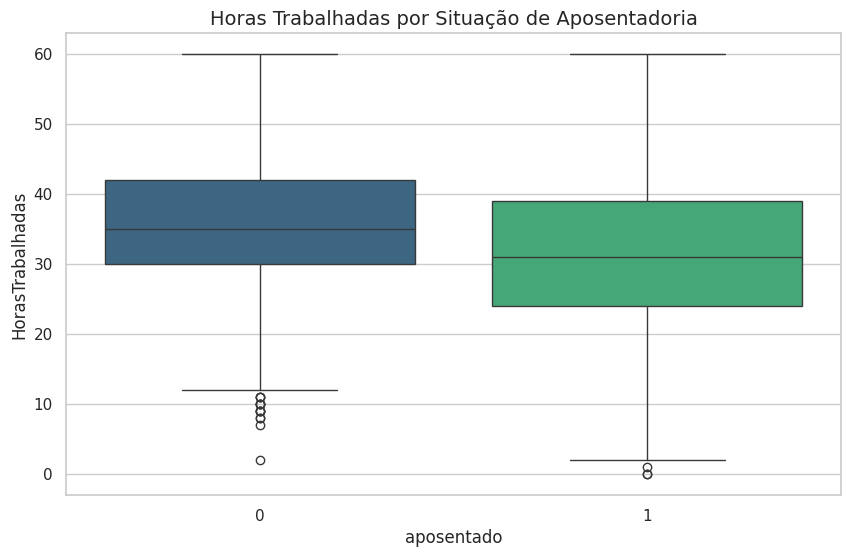

In [ ]:
# ==============================================================================
# 28. HORAS TRABALHADAS x APOSENTADORIA
# ==============================================================================

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="aposentado",
    y="HorasTrabalhadas",
    palette="viridis"
)

plt.title("Horas Trabalhadas por Situação de Aposentadoria")

plt.show()


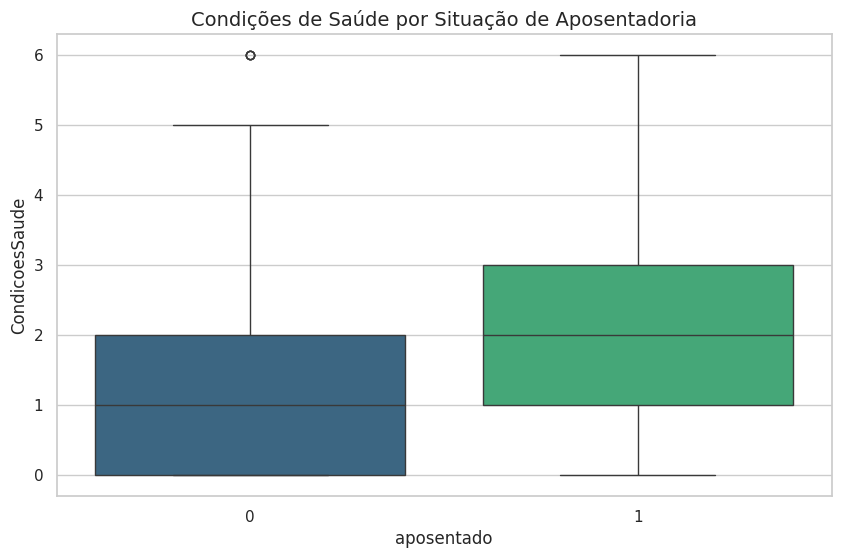

In [ ]:
# ==============================================================================
# 29. CONDIÇÕES DE SAÚDE x APOSENTADORIA
# ==============================================================================

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="aposentado",
    y="CondicoesSaude",
    palette="viridis"
)

plt.title("Condições de Saúde por Situação de Aposentadoria")

plt.show()


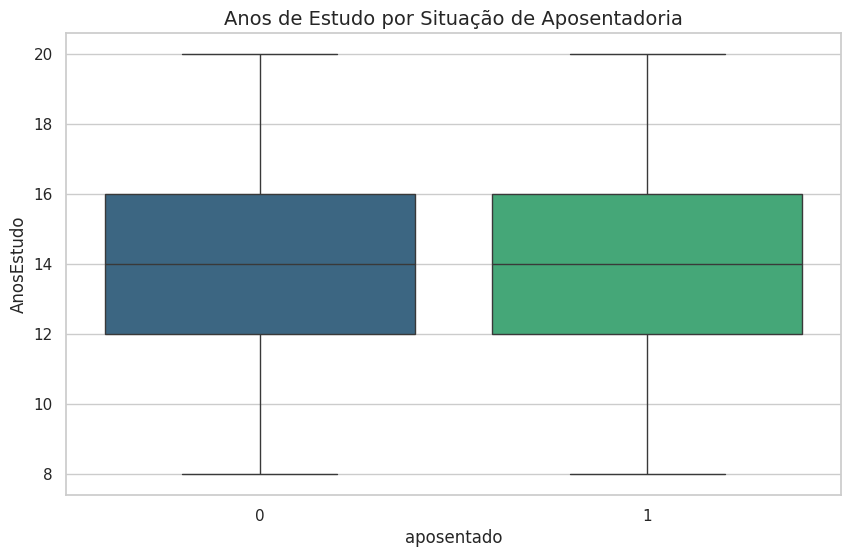

In [ ]:
# ==============================================================================
# 30. ESCOLARIDADE x APOSENTADORIA
# ==============================================================================

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="aposentado",
    y="AnosEstudo",
    palette="viridis"
)

plt.title("Anos de Estudo por Situação de Aposentadoria")

plt.show()


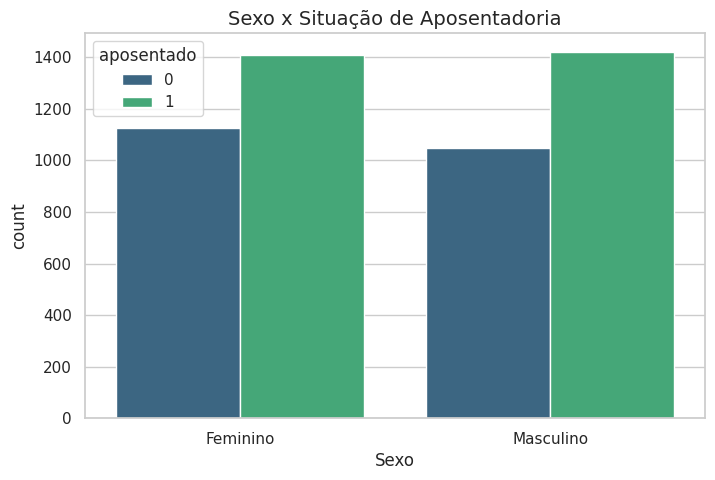

In [ ]:
# ==============================================================================
# 31. SEXO x APOSENTADORIA
# ==============================================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Sexo",
    hue="aposentado",
    palette="viridis"
)

plt.title("Sexo x Situação de Aposentadoria")

plt.show()



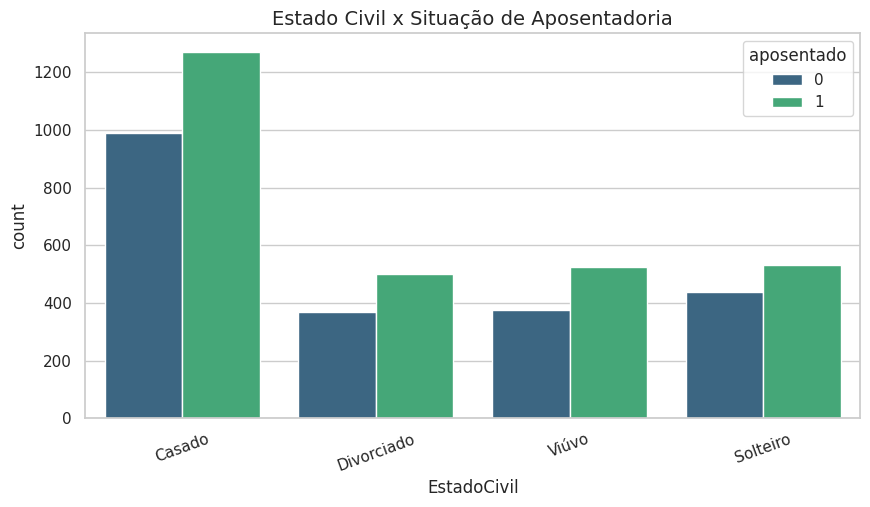

In [ ]:
# ==============================================================================
# 32. ESTADO CIVIL x APOSENTADORIA
# ==============================================================================

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="EstadoCivil",
    hue="aposentado",
    palette="viridis"
)

plt.title("Estado Civil x Situação de Aposentadoria")

plt.xticks(rotation=20)

plt.show()



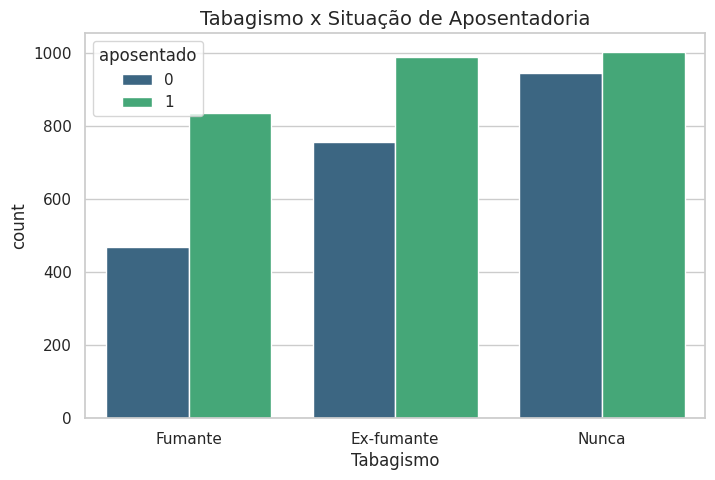

In [ ]:
# ==============================================================================
# 33. TABAGISMO x APOSENTADORIA
# ==============================================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Tabagismo",
    hue="aposentado",
    palette="viridis"
)

plt.title("Tabagismo x Situação de Aposentadoria")

plt.show()


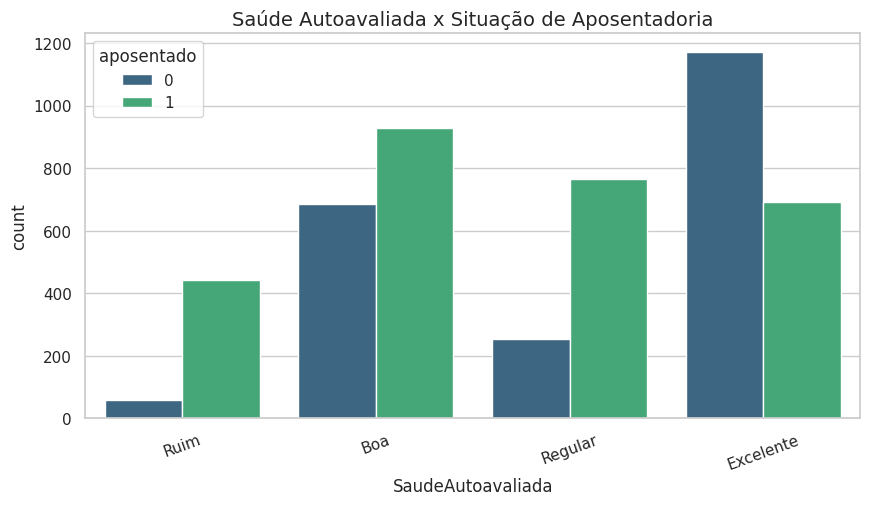

In [ ]:
# ==============================================================================
# 34. SAÚDE AUTOAVALIADA x APOSENTADORIA
# ==============================================================================

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="SaudeAutoavaliada",
    hue="aposentado",
    palette="viridis"
)

plt.title("Saúde Autoavaliada x Situação de Aposentadoria")

plt.xticks(rotation=20)

plt.show()

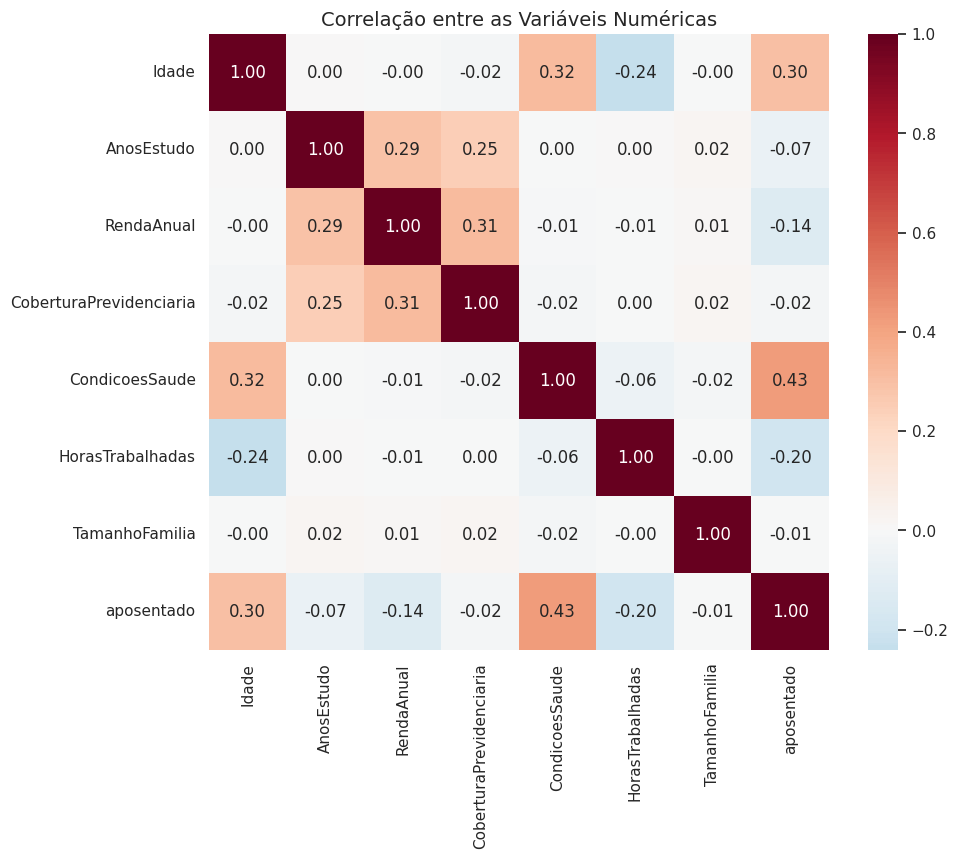

In [ ]:
# ==============================================================================
# 35. MATRIZ DE CORRELAÇÃO
# ==============================================================================

plt.figure(figsize=(10,8))

corr = df.corr(numeric_only=True)

sns.heatmap(

    corr,

    annot=True,

    cmap="RdBu_r",

    center=0,

    fmt=".2f"

)

plt.title("Correlação entre as Variáveis Numéricas")

plt.show()



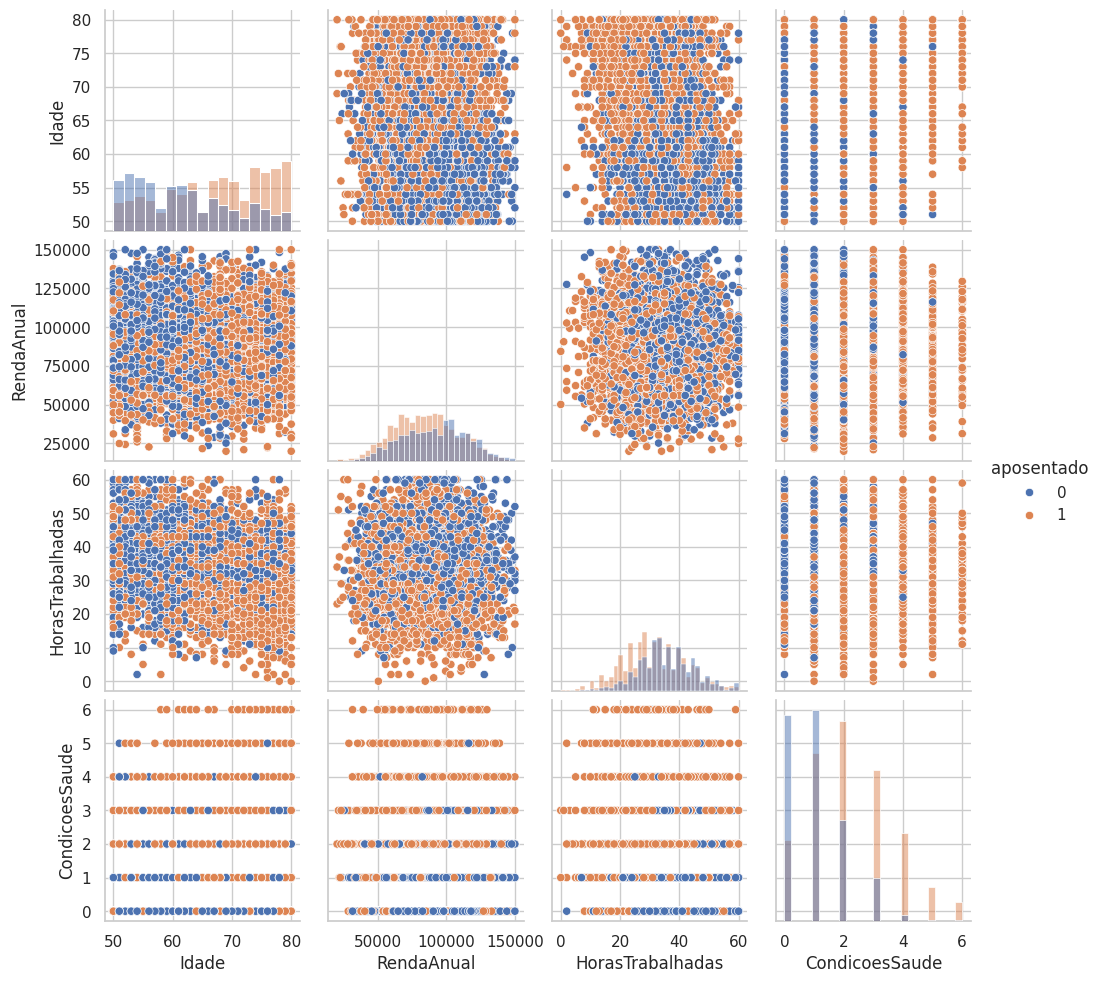

In [ ]:

# ==============================================================================
# 36. PAIRPLOT
# ==============================================================================

variaveis = [

    "Idade",

    "RendaAnual",

    "HorasTrabalhadas",

    "CondicoesSaude",

    "aposentado"

]

sns.pairplot(

    df[variaveis],

    hue="aposentado",

    diag_kind="hist"

)

plt.show()



In [ ]:
# ==============================================================================
# 37. MATRIZ DE CORRELAÇÃO COM A VARIÁVEL ALVO
# ==============================================================================

corr_target = (

    df.corr(numeric_only=True)["aposentado"]

    .sort_values(ascending=False)

)

print("="*90)
print("CORRELAÇÃO COM A VARIÁVEL APOSENTADO")
print("="*90)

display(corr_target)



CORRELAÇÃO COM A VARIÁVEL APOSENTADO


,aposentado
aposentado,1.000000
CondicoesSaude,0.425385
Idade,0.299730
TamanhoFamilia,-0.005270
CoberturaPrevidenciaria,-0.021084
AnosEstudo,-0.065622
RendaAnual,-0.136871
HorasTrabalhadas,-0.195302


In [ ]:

# ==============================================================================
# 38. MÉDIAS DOS APOSENTADOS
# ==============================================================================

print("="*90)
print("MÉDIAS DAS VARIÁVEIS NUMÉRICAS POR SITUAÇÃO")
print("="*90)

display(

    df.groupby("aposentado")[

        [

            "Idade",

            "AnosEstudo",

            "RendaAnual",

            "CondicoesSaude",

            "HorasTrabalhadas",

            "TamanhoFamilia"

        ]

    ].mean().round(2)

)



MÉDIAS DAS VARIÁVEIS NUMÉRICAS POR SITUAÇÃO


,Idade,AnosEstudo,RendaAnual,CondicoesSaude,HorasTrabalhadas,TamanhoFamilia
aposentado,,,,,,
0,61.88,14.19,91126.26,1.02,35.72,3.55
1,67.31,13.80,84438.32,2.24,31.63,3.54


In [ ]:
# ==============================================================================
# 39. PERFIL DOS APOSENTADOS
# ==============================================================================

perfil = df[df["aposentado"] == 1]

print("="*90)
print("PERFIL DOS SEGURADOS APOSENTADOS")
print("="*90)

display(

    perfil.describe().T

)


PERFIL DOS SEGURADOS APOSENTADOS


,count,mean,std,min,25%,50%,75%,max
Idade,2829.0,67.306822,8.700048,50.0,60.0,68.0,75.0,80.0
AnosEstudo,2829.0,13.801343,2.924822,8.0,12.0,14.0,16.0,20.0
RendaAnual,2829.0,84438.319194,23810.566397,20000.0,67114.0,83813.0,100705.0,150000.0
CoberturaPrevidenciaria,2829.0,0.604807,0.488978,0.0,0.0,1.0,1.0,1.0
CondicoesSaude,2829.0,2.235065,1.452292,0.0,1.0,2.0,3.0,6.0
HorasTrabalhadas,2829.0,31.627430,10.750799,0.0,24.0,31.0,39.0,60.0
TamanhoFamilia,2829.0,3.535171,1.710248,1.0,2.0,4.0,5.0,6.0
aposentado,2829.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0


In [ ]:
# ==============================================================================
# 40. PERFIL DOS NÃO APOSENTADOS
# ==============================================================================

ativos = df[df["aposentado"] == 0]

print("="*90)
print("PERFIL DOS SEGURADOS NÃO APOSENTADOS")
print("="*90)

display(

    ativos.describe().T

)



PERFIL DOS SEGURADOS NÃO APOSENTADOS


,count,mean,std,min,25%,50%,75%,max
Idade,2171.0,61.884385,8.365333,50.0,55.0,61.0,68.0,80.0
AnosEstudo,2171.0,14.185168,2.851918,8.0,12.0,14.0,16.0,20.0
RendaAnual,2171.0,91126.263012,24235.285480,23704.0,72998.0,91810.0,108760.0,150000.0
CoberturaPrevidenciaria,2171.0,0.625518,0.484100,0.0,0.0,1.0,1.0,1.0
CondicoesSaude,2171.0,1.020728,1.014655,0.0,0.0,1.0,2.0,6.0
HorasTrabalhadas,2171.0,35.723630,9.427780,2.0,30.0,35.0,42.0,60.0
TamanhoFamilia,2171.0,3.553201,1.677254,1.0,2.0,4.0,5.0,6.0
aposentado,2171.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


In [ ]:

# ==============================================================================
# 41. CONCLUSÕES DA EDA
# ==============================================================================

print("="*90)
print("ANÁLISE EXPLORATÓRIA FINALIZADA")
print("="*90)

print("""

A Análise Exploratória permitiu:

✓ Compreender a distribuição das variáveis.

✓ Identificar diferenças entre aposentados e não aposentados.

✓ Avaliar possíveis relações entre variáveis.

✓ Identificar atributos potencialmente relevantes.

✓ Verificar possíveis padrões antes da modelagem.

✓ Fundamentar tecnicamente a construção dos modelos preditivos.

A base encontra-se pronta para a etapa de Pré-processamento.

""")

ANÁLISE EXPLORATÓRIA FINALIZADA


A Análise Exploratória permitiu:

✓ Compreender a distribuição das variáveis.

✓ Identificar diferenças entre aposentados e não aposentados.

✓ Avaliar possíveis relações entre variáveis.

✓ Identificar atributos potencialmente relevantes.

✓ Verificar possíveis padrões antes da modelagem.

✓ Fundamentar tecnicamente a construção dos modelos preditivos.

A base encontra-se pronta para a etapa de Pré-processamento.




## **Capítulo 2 - Pré-processamento dos Dados**

In [24]:
# ==============================================================================
# 1. CRIAÇÃO DE UMA CÓPIA DA BASE
# ==============================================================================

dados = df.copy()

print("Cópia da base criada com sucesso.")

Cópia da base criada com sucesso.


In [25]:
# ==============================================================================
# 2. IDENTIFICAÇÃO DA VARIÁVEL ALVO
# ==============================================================================

print("="*90)
print("VARIÁVEL ALVO")
print("="*90)

target = "aposentado"

print(f"Variável resposta: {target}")

VARIÁVEL ALVO
Variável resposta: aposentado


In [26]:
# ==============================================================================
# 3. SEPARAÇÃO ENTRE VARIÁVEIS EXPLICATIVAS E VARIÁVEL RESPOSTA
# ==============================================================================

X = dados.drop(columns=[target])

y = dados[target]

print("="*90)
print("DIMENSÕES")
print("="*90)

print(f"X : {X.shape}")

print(f"y : {y.shape}")

DIMENSÕES
X : (5000, 11)
y : (5000,)


In [27]:
# ==============================================================================
# 4. IDENTIFICAÇÃO DOS TIPOS DAS VARIÁVEIS
# ==============================================================================

variaveis_numericas = [

    "Idade",

    "AnosEstudo",

    "RendaAnual",

    "CondicoesSaude",

    "HorasTrabalhadas",

    "TamanhoFamilia"

]

variaveis_binarias = [

    "CoberturaPrevidenciaria"

]

variaveis_categoricas = [

    "Sexo",

    "EstadoCivil",

    "SaudeAutoavaliada",

    "Tabagismo"

]

print("="*90)
print("VARIÁVEIS NUMÉRICAS")
print("="*90)

print(variaveis_numericas)

print("="*90)
print("VARIÁVEIS BINÁRIAS")
print("="*90)

print(variaveis_binarias)

print("="*90)
print("VARIÁVEIS CATEGÓRICAS")
print("="*90)

print(variaveis_categoricas)

VARIÁVEIS NUMÉRICAS
['Idade', 'AnosEstudo', 'RendaAnual', 'CondicoesSaude', 'HorasTrabalhadas', 'TamanhoFamilia']
VARIÁVEIS BINÁRIAS
['CoberturaPrevidenciaria']
VARIÁVEIS CATEGÓRICAS
['Sexo', 'EstadoCivil', 'SaudeAutoavaliada', 'Tabagismo']


In [28]:
# ==============================================================================
# 5. CODIFICAÇÃO DAS VARIÁVEIS CATEGÓRICAS
# ==============================================================================

print("="*90)
print("ONE HOT ENCODING")
print("="*90)

X = pd.get_dummies(

    X,

    columns=variaveis_categoricas,

    drop_first=True,

    dtype=int

)

print("Dimensão após One-Hot Encoding:")

print(X.shape)

display(X.head())


ONE HOT ENCODING
Dimensão após One-Hot Encoding:
(5000, 16)


,Idade,AnosEstudo,RendaAnual,CoberturaPrevidenciaria,CondicoesSaude,HorasTrabalhadas,TamanhoFamilia,Sexo_Masculino,EstadoCivil_Divorciado,EstadoCivil_Solteiro,EstadoCivil_Viúvo,SaudeAutoavaliada_Excelente,SaudeAutoavaliada_Regular,SaudeAutoavaliada_Ruim,Tabagismo_Fumante,Tabagismo_Nunca
0,52,8,75232,1,3,36,4,0,0,0,0,0,0,1,1,0
1,73,17,85860,1,2,39,2,0,1,0,0,0,0,0,0,0
2,70,18,62156,1,2,19,5,1,1,0,0,0,0,0,0,1
3,63,13,117061,1,6,34,4,1,0,0,0,0,0,1,0,0
4,63,16,116966,1,2,37,3,1,0,0,0,0,1,0,0,0


In [29]:
# ==============================================================================
# 6. CONFERÊNCIA DAS NOVAS COLUNAS
# ==============================================================================

print("="*90)
print("COLUNAS GERADAS")
print("="*90)

for coluna in X.columns:

    print(coluna)

COLUNAS GERADAS
Idade
AnosEstudo
RendaAnual
CoberturaPrevidenciaria
CondicoesSaude
HorasTrabalhadas
TamanhoFamilia
Sexo_Masculino
EstadoCivil_Divorciado
EstadoCivil_Solteiro
EstadoCivil_Viúvo
SaudeAutoavaliada_Excelente
SaudeAutoavaliada_Regular
SaudeAutoavaliada_Ruim
Tabagismo_Fumante
Tabagismo_Nunca


In [30]:
# ==============================================================================
# 7. DIVISÃO ENTRE TREINO E TESTE
# ==============================================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.30,

    random_state=42,

    stratify=y

)

print("="*90)
print("TREINO E TESTE")
print("="*90)

print(f"Treino X : {X_train.shape}")

print(f"Teste  X : {X_test.shape}")

print(f"Treino y : {y_train.shape}")

print(f"Teste  y : {y_test.shape}")

TREINO E TESTE
Treino X : (3500, 16)
Teste  X : (1500, 16)
Treino y : (3500,)
Teste  y : (1500,)


In [31]:
# ==============================================================================
# 8. VERIFICAÇÃO DO BALANCEAMENTO
# ==============================================================================

print("="*90)
print("BALANCEAMENTO")
print("="*90)

print("Treino")

display(

    y_train.value_counts(normalize=True)

)

print("Teste")

display(

    y_test.value_counts(normalize=True)

)

BALANCEAMENTO
Treino


,proportion
aposentado,
1,0.565714
0,0.434286


Teste


,proportion
aposentado,
1,0.566
0,0.434


In [32]:
# ==============================================================================
# 9. PADRONIZAÇÃO DAS VARIÁVEIS NUMÉRICAS
# ==============================================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train.copy()

X_test_scaled = X_test.copy()

X_train_scaled[variaveis_numericas] = scaler.fit_transform(

    X_train[variaveis_numericas]

)

X_test_scaled[variaveis_numericas] = scaler.transform(

    X_test[variaveis_numericas]

)

print("="*90)
print("NORMALIZAÇÃO CONCLUÍDA")
print("="*90)

display(

    X_train_scaled.head()

)


NORMALIZAÇÃO CONCLUÍDA


,Idade,AnosEstudo,RendaAnual,CoberturaPrevidenciaria,CondicoesSaude,HorasTrabalhadas,TamanhoFamilia,Sexo_Masculino,EstadoCivil_Divorciado,EstadoCivil_Solteiro,EstadoCivil_Viúvo,SaudeAutoavaliada_Excelente,SaudeAutoavaliada_Regular,SaudeAutoavaliada_Ruim,Tabagismo_Fumante,Tabagismo_Nunca
4102,-1.095433,0.378171,-0.534785,1,-0.494785,0.512920,1.463003,0,0,0,1,1,0,0,0,1
342,0.465875,-1.013260,-1.076316,0,0.208606,-0.541288,0.279207,1,0,1,0,0,0,0,0,1
4524,1.023485,1.421744,-0.786247,0,0.911996,-1.883008,0.871105,0,0,0,0,0,0,1,1,0
3412,-0.983911,-0.665402,-0.776461,1,-0.494785,-0.157940,1.463003,0,1,0,0,1,0,0,0,1
2510,-0.983911,2.117460,0.097668,1,-0.494785,1.279617,-1.496487,0,0,0,1,1,0,0,0,0


In [33]:
# ==============================================================================
# 10. CONFERÊNCIA DAS MÉDIAS APÓS PADRONIZAÇÃO
# ==============================================================================

print("="*90)
print("MÉDIAS DAS VARIÁVEIS PADRONIZADAS")
print("="*90)

display(

    X_train_scaled[variaveis_numericas].mean()

)

MÉDIAS DAS VARIÁVEIS PADRONIZADAS


,0
Idade,7.501301e-16
AnosEstudo,-2.801569e-16
RendaAnual,-8.120488e-18
CondicoesSaude,-8.323501e-17
HorasTrabalhadas,-3.166990e-16
TamanhoFamilia,-1.177471e-16


In [34]:
# ==============================================================================
# 11. CONFERÊNCIA DOS DESVIOS PADRÃO
# ==============================================================================

print("="*90)
print("DESVIOS PADRÃO")
print("="*90)

display(

    X_train_scaled[variaveis_numericas].std()

)


DESVIOS PADRÃO


,0
Idade,1.000143
AnosEstudo,1.000143
RendaAnual,1.000143
CondicoesSaude,1.000143
HorasTrabalhadas,1.000143
TamanhoFamilia,1.000143


In [35]:
# ==============================================================================
# 12. CONFERÊNCIA FINAL
# ==============================================================================

print("="*90)
print("VERIFICAÇÃO FINAL")
print("="*90)

print("Valores ausentes em X_train:")

print(

    X_train_scaled.isnull().sum().sum()

)

print("Valores ausentes em X_test:")

print(

    X_test_scaled.isnull().sum().sum()

)

VERIFICAÇÃO FINAL
Valores ausentes em X_train:
0
Valores ausentes em X_test:
0


In [36]:
# ==============================================================================
# 13. RESUMO DA ETAPA
# ==============================================================================

print("="*90)
print("PRÉ-PROCESSAMENTO FINALIZADO")
print("="*90)

print("""

✓ Variável resposta separada

✓ Variáveis explicativas separadas

✓ Variáveis categóricas codificadas

✓ One-Hot Encoding aplicado

✓ Base dividida em treino e teste

✓ Balanceamento preservado com Stratify

✓ Variáveis numéricas padronizadas

✓ Dados preparados para Machine Learning

""")

PRÉ-PROCESSAMENTO FINALIZADO


✓ Variável resposta separada

✓ Variáveis explicativas separadas

✓ Variáveis categóricas codificadas

✓ One-Hot Encoding aplicado

✓ Base dividida em treino e teste

✓ Balanceamento preservado com Stratify

✓ Variáveis numéricas padronizadas

✓ Dados preparados para Machine Learning





## **Capítulo 3 - Construção e Treinamento dos Modelos**



In [37]:
# ==============================================================================
# 1. IMPORTAÇÃO DOS ALGORITMOS
# ==============================================================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [38]:
# ==============================================================================
# 2. CONFIGURAÇÃO DOS MODELOS
# ==============================================================================

modelo_logistico = LogisticRegression(

    random_state=42,

    max_iter=1000

)

modelo_arvore = DecisionTreeClassifier(

    random_state=42,

    max_depth=5

)

modelo_random = RandomForestClassifier(

    random_state=42,

    n_estimators=300,

    max_depth=8,

    n_jobs=-1

)

print("Modelos configurados com sucesso.")

Modelos configurados com sucesso.


In [39]:
# ==============================================================================
# 3. TREINAMENTO DA REGRESSÃO LOGÍSTICA
# ==============================================================================

print("="*90)
print("TREINANDO REGRESSÃO LOGÍSTICA")
print("="*90)

modelo_logistico.fit(

    X_train_scaled,

    y_train

)

print("Treinamento concluído.")

TREINANDO REGRESSÃO LOGÍSTICA
Treinamento concluído.


In [40]:
# ==============================================================================
# 4. TREINAMENTO DA ÁRVORE DE DECISÃO
# ==============================================================================

print("="*90)
print("TREINANDO ÁRVORE DE DECISÃO")
print("="*90)

modelo_arvore.fit(

    X_train,

    y_train

)

print("Treinamento concluído.")

TREINANDO ÁRVORE DE DECISÃO
Treinamento concluído.


In [41]:
# ==============================================================================
# 5. TREINAMENTO RANDOM FOREST
# ==============================================================================

print("="*90)
print("TREINANDO RANDOM FOREST")
print("="*90)

modelo_random.fit(

    X_train,

    y_train

)

print("Treinamento concluído.")

TREINANDO RANDOM FOREST
Treinamento concluído.


In [42]:
# ==============================================================================
# 6. PREVISÕES - REGRESSÃO LOGÍSTICA
# ==============================================================================

pred_log = modelo_logistico.predict(

    X_test_scaled

)

prob_log = modelo_logistico.predict_proba(

    X_test_scaled

)[:,1]

In [43]:
# ==============================================================================
# 7. PREVISÕES - ÁRVORE
# ==============================================================================

pred_tree = modelo_arvore.predict(

    X_test

)

prob_tree = modelo_arvore.predict_proba(

    X_test

)[:,1]

In [44]:
# ==============================================================================
# 8. PREVISÕES - RANDOM FOREST
# ==============================================================================

pred_rf = modelo_random.predict(

    X_test

)

prob_rf = modelo_random.predict_proba(

    X_test

)[:,1]

In [45]:
# ==============================================================================
# 9. ORGANIZAÇÃO DAS PREVISÕES
# ==============================================================================

predicoes = {

    "Regressão Logística": pred_log,

    "Árvore de Decisão": pred_tree,

    "Random Forest": pred_rf

}

probabilidades = {

    "Regressão Logística": prob_log,

    "Árvore de Decisão": prob_tree,

    "Random Forest": prob_rf

}

print("="*90)
print("PREDIÇÕES ARMAZENADAS")
print("="*90)

for modelo in predicoes.keys():

    print(modelo)

PREDIÇÕES ARMAZENADAS
Regressão Logística
Árvore de Decisão
Random Forest


In [46]:
# ==============================================================================
# 10. AMOSTRA DAS PREVISÕES
# ==============================================================================

resultado = pd.DataFrame({

    "Valor Real": y_test.values,

    "Regressão Logística": pred_log,

    "Árvore": pred_tree,

    "Random Forest": pred_rf

})

print("="*90)
print("AMOSTRA DAS PREVISÕES")
print("="*90)

display(resultado.head(20))

AMOSTRA DAS PREVISÕES


,Valor Real,Regressão Logística,Árvore,Random Forest
0,1,0,0,0
1,1,1,1,1
2,0,0,1,0
3,1,1,1,1
4,1,1,1,1
5,0,1,1,1
6,1,0,1,1
7,0,1,1,1
8,1,1,1,1
9,1,1,1,1


In [47]:
# ==============================================================================
# 11. DISTRIBUIÇÃO DAS PREVISÕES
# ==============================================================================

for nome, previsao in predicoes.items():

    print("="*90)

    print(nome)

    print("="*90)

    display(

        pd.Series(previsao).value_counts()

    )

Regressão Logística


,count
1,920
0,580


Árvore de Decisão


,count
1,893
0,607


Random Forest


,count
1,916
0,584


In [48]:
# ==============================================================================
# 12. PROBABILIDADES MÉDIAS
# ==============================================================================

probabilidades_medias = pd.DataFrame({

    "Modelo":[

        "Regressão Logística",

        "Árvore de Decisão",

        "Random Forest"

    ],

    "Probabilidade Média":[

        prob_log.mean(),

        prob_tree.mean(),

        prob_rf.mean()

    ]

})

print("="*90)
print("PROBABILIDADE MÉDIA PREVISTA")
print("="*90)

display(probabilidades_medias)

PROBABILIDADE MÉDIA PREVISTA


,Modelo,Probabilidade Média
0,Regressão Logística,0.577990
1,Árvore de Decisão,0.571631
2,Random Forest,0.571134


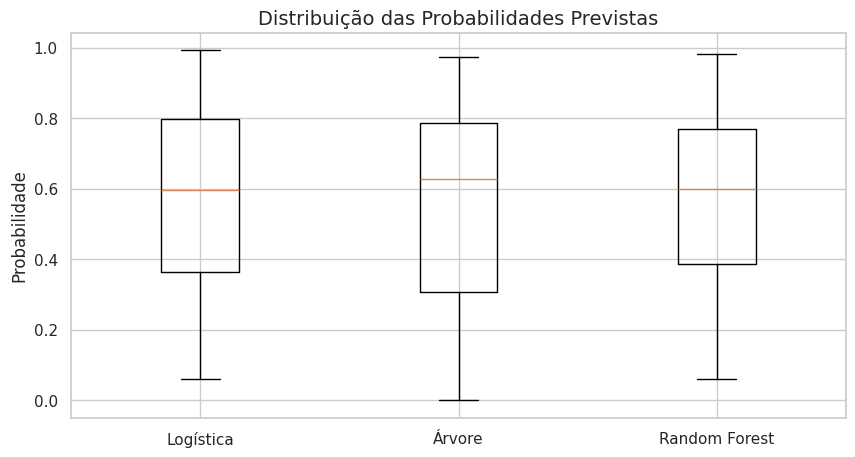

In [49]:
# ==============================================================================
# 13. COMPARAÇÃO DAS PROBABILIDADES
# ==============================================================================

plt.figure(figsize=(10,5))

plt.boxplot(

    [

        prob_log,

        prob_tree,

        prob_rf

    ],

    labels=[

        "Logística",

        "Árvore",

        "Random Forest"

    ]

)

plt.title("Distribuição das Probabilidades Previstas")

plt.ylabel("Probabilidade")

plt.show()

In [50]:
# ==============================================================================
# 14. IMPORTÂNCIA DAS VARIÁVEIS - RANDOM FOREST
# ==============================================================================

importancias = pd.Series(

    modelo_random.feature_importances_,

    index=X_train.columns

).sort_values(ascending=False)

print("="*90)
print("10 VARIÁVEIS MAIS IMPORTANTES")
print("="*90)

display(

    importancias.head(10)

)

10 VARIÁVEIS MAIS IMPORTANTES


,0
CondicoesSaude,0.250423
Idade,0.156251
RendaAnual,0.138081
HorasTrabalhadas,0.134627
SaudeAutoavaliada_Excelente,0.081979
AnosEstudo,0.051656
SaudeAutoavaliada_Ruim,0.041156
TamanhoFamilia,0.036006
SaudeAutoavaliada_Regular,0.028322
CoberturaPrevidenciaria,0.015423


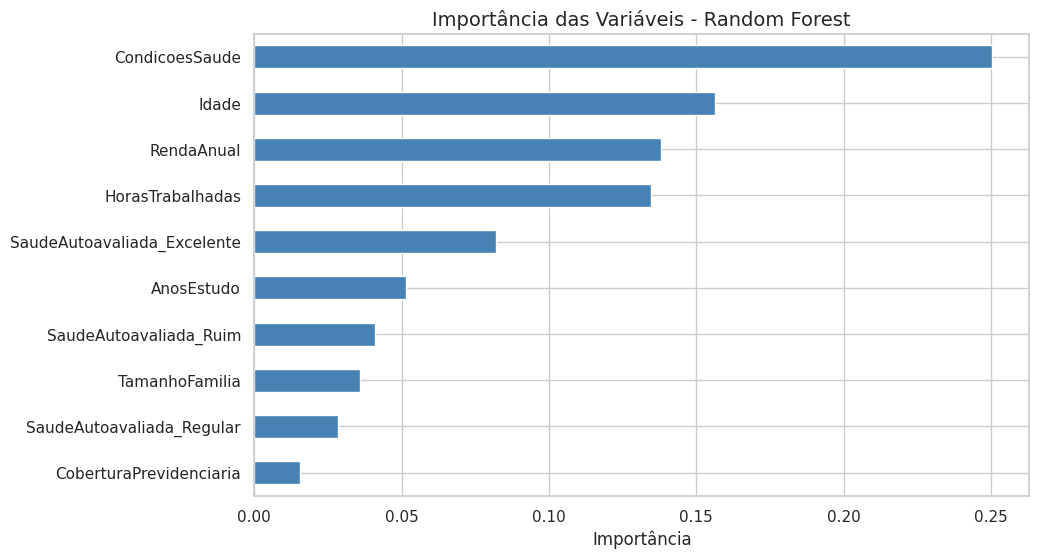

In [51]:
# ==============================================================================
# 15. GRÁFICO DAS IMPORTÂNCIAS
# ==============================================================================

plt.figure(figsize=(10,6))

importancias.head(10).sort_values().plot(

    kind="barh",

    color="steelblue"

)

plt.title("Importância das Variáveis - Random Forest")

plt.xlabel("Importância")

plt.show()

In [52]:
# ==============================================================================
# 16. RESUMO DA ETAPA
# ==============================================================================

print("="*90)
print("CAPÍTULO 3 CONCLUÍDO")
print("="*90)

print("""

✓ Regressão Logística treinada

✓ Árvore de Decisão treinada

✓ Random Forest treinado

✓ Previsões realizadas

✓ Probabilidades calculadas

✓ Resultados organizados

✓ Importância das variáveis calculada

Base pronta para avaliação dos modelos.

""")

CAPÍTULO 3 CONCLUÍDO


✓ Regressão Logística treinada

✓ Árvore de Decisão treinada

✓ Random Forest treinado

✓ Previsões realizadas

✓ Probabilidades calculadas

✓ Resultados organizados

✓ Importância das variáveis calculada

Base pronta para avaliação dos modelos.




## **Capítulo 4 - Avaliação dos Modelos**

In [53]:
# ==============================================================================
# IMPORTAÇÃO DAS MÉTRICAS
# ==============================================================================

from sklearn.metrics import (

    confusion_matrix,

    accuracy_score,

    precision_score,

    recall_score,

    f1_score,

    roc_auc_score,

    ConfusionMatrixDisplay

)

In [54]:
# ==============================================================================
# DICIONÁRIOS PARA ARMAZENAMENTO
# ==============================================================================

metricas = []

matrizes = {}

In [55]:
# ==============================================================================
# AVALIAÇÃO DOS MODELOS
# ==============================================================================

for nome in predicoes.keys():

    print("\n")

    print("="*90)

    print(nome.upper())

    print("="*90)

    y_pred = predicoes[nome]

    y_prob = probabilidades[nome]

    cm = confusion_matrix(

        y_test,

        y_pred

    )

    matrizes[nome] = cm

    acuracia = accuracy_score(

        y_test,

        y_pred

    )

    precisao = precision_score(

        y_test,

        y_pred

    )

    recall = recall_score(

        y_test,

        y_pred

    )

    f1 = f1_score(

        y_test,

        y_pred

    )

    auc = roc_auc_score(

        y_test,

        y_prob

    )

    metricas.append({

        "Modelo":nome,

        "Acurácia":acuracia,

        "Precisão":precisao,

        "Recall":recall,

        "F1-Score":f1,

        "AUC":auc

    })

    print(f"Acurácia : {acuracia:.4f}")

    print(f"Precisão : {precisao:.4f}")

    print(f"Recall   : {recall:.4f}")

    print(f"F1-Score : {f1:.4f}")

    print(f"AUC       : {auc:.4f}")



REGRESSÃO LOGÍSTICA
Acurácia : 0.7260
Precisão : 0.7380
Recall   : 0.7998
F1-Score : 0.7677
AUC       : 0.7981


ÁRVORE DE DECISÃO
Acurácia : 0.7213
Precisão : 0.7413
Recall   : 0.7797
F1-Score : 0.7600
AUC       : 0.7912


RANDOM FOREST
Acurácia : 0.7367
Precisão : 0.7478
Recall   : 0.8068
F1-Score : 0.7762
AUC       : 0.8107


In [56]:
# ==============================================================================
# TABELA COMPARATIVA
# ==============================================================================

df_metricas = pd.DataFrame(metricas)

df_metricas = df_metricas.round(4)

print("="*90)

print("TABELA COMPARATIVA")

print("="*90)

display(df_metricas)

TABELA COMPARATIVA


,Modelo,Acurácia,Precisão,Recall,F1-Score,AUC
0,Regressão Logística,0.7260,0.7380,0.7998,0.7677,0.7981
1,Árvore de Decisão,0.7213,0.7413,0.7797,0.7600,0.7912
2,Random Forest,0.7367,0.7478,0.8068,0.7762,0.8107


MATRIZ DE CONFUSÃO - Regressão Logística


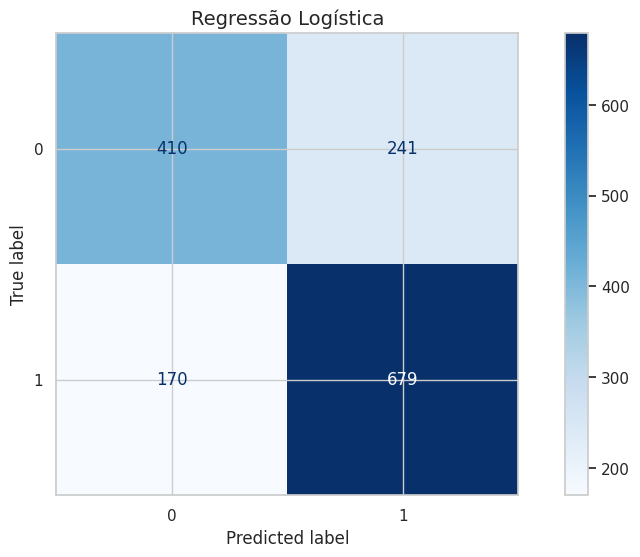

MATRIZ DE CONFUSÃO - Árvore de Decisão


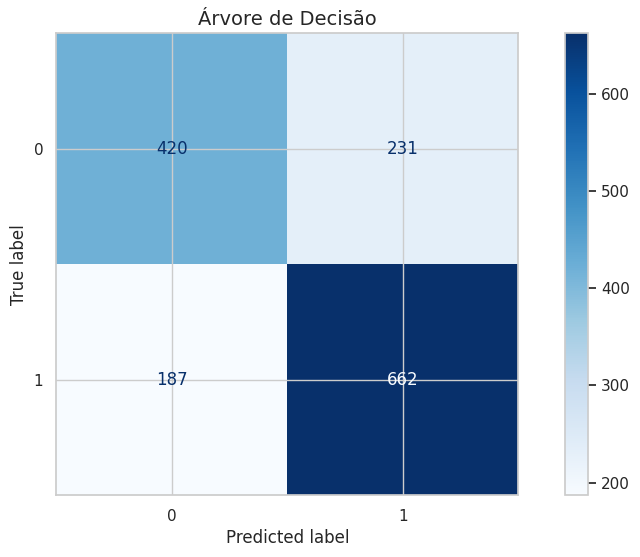

MATRIZ DE CONFUSÃO - Random Forest


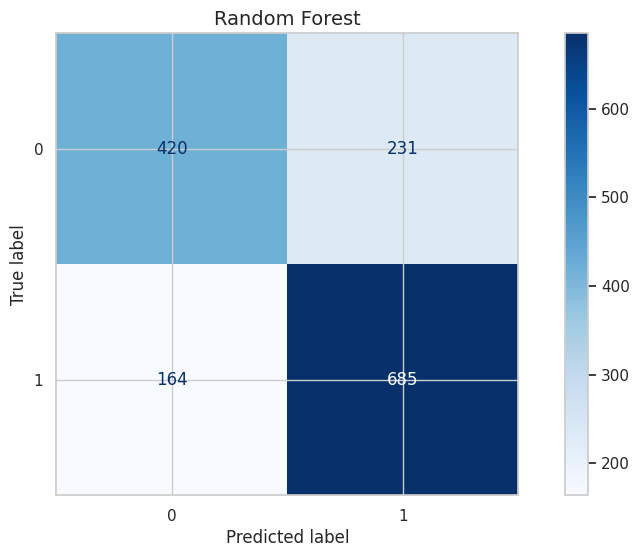

In [57]:
# ==============================================================================
# MATRIZES DE CONFUSÃO
# ==============================================================================

for nome in matrizes.keys():

    print("="*90)

    print(f"MATRIZ DE CONFUSÃO - {nome}")

    print("="*90)

    disp = ConfusionMatrixDisplay(

        confusion_matrix=matrizes[nome]

    )

    disp.plot(

        cmap="Blues",

        values_format="d"

    )

    plt.title(nome)

    plt.show()

In [58]:
# ==============================================================================
# MATRIZES DETALHADAS
# ==============================================================================

for nome in matrizes.keys():

    cm = matrizes[nome]

    vn = cm[0,0]

    fp = cm[0,1]

    fn = cm[1,0]

    vp = cm[1,1]

    print("="*90)

    print(nome)

    print("="*90)

    print(f"Verdadeiros Negativos : {vn}")

    print(f"Falsos Positivos      : {fp}")

    print(f"Falsos Negativos      : {fn}")

    print(f"Verdadeiros Positivos : {vp}")

Regressão Logística
Verdadeiros Negativos : 410
Falsos Positivos      : 241
Falsos Negativos      : 170
Verdadeiros Positivos : 679
Árvore de Decisão
Verdadeiros Negativos : 420
Falsos Positivos      : 231
Falsos Negativos      : 187
Verdadeiros Positivos : 662
Random Forest
Verdadeiros Negativos : 420
Falsos Positivos      : 231
Falsos Negativos      : 164
Verdadeiros Positivos : 685


In [59]:
# ==============================================================================
# RANKING DOS MODELOS
# ==============================================================================

ranking = df_metricas.sort_values(

    by="AUC",

    ascending=False

)

print("="*90)

print("RANKING DOS MODELOS")

print("="*90)

display(ranking)

RANKING DOS MODELOS


,Modelo,Acurácia,Precisão,Recall,F1-Score,AUC
2,Random Forest,0.7367,0.7478,0.8068,0.7762,0.8107
0,Regressão Logística,0.7260,0.7380,0.7998,0.7677,0.7981
1,Árvore de Decisão,0.7213,0.7413,0.7797,0.7600,0.7912


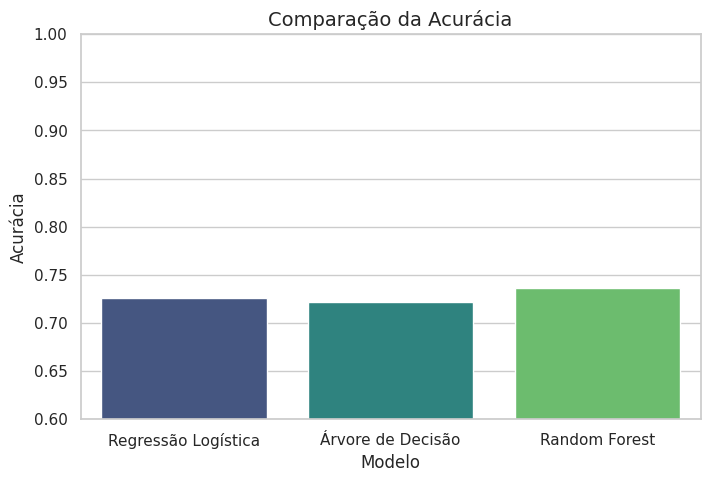

In [60]:
# ==============================================================================
# GRÁFICO DE ACURÁCIA
# ==============================================================================

plt.figure(figsize=(8,5))

sns.barplot(

    data=df_metricas,

    x="Modelo",

    y="Acurácia",

    palette="viridis"

)

plt.ylim(0.60,1)

plt.title("Comparação da Acurácia")

plt.show()

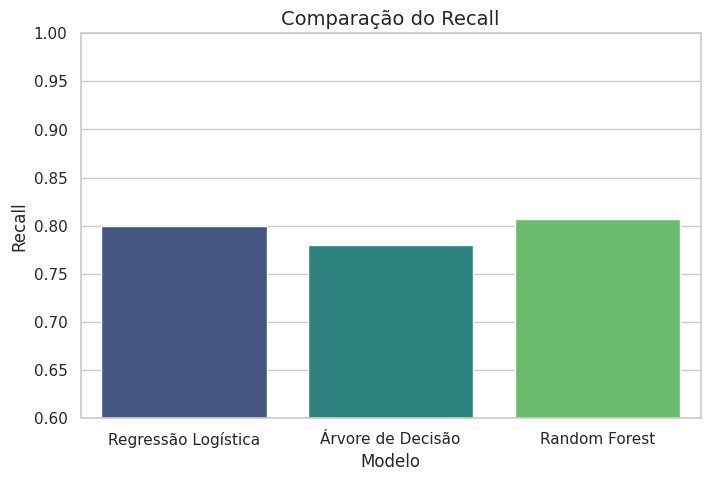

In [61]:
# ==============================================================================
# GRÁFICO DE RECALL
# ==============================================================================

plt.figure(figsize=(8,5))

sns.barplot(

    data=df_metricas,

    x="Modelo",

    y="Recall",

    palette="viridis"

)

plt.ylim(0.60,1)

plt.title("Comparação do Recall")

plt.show()

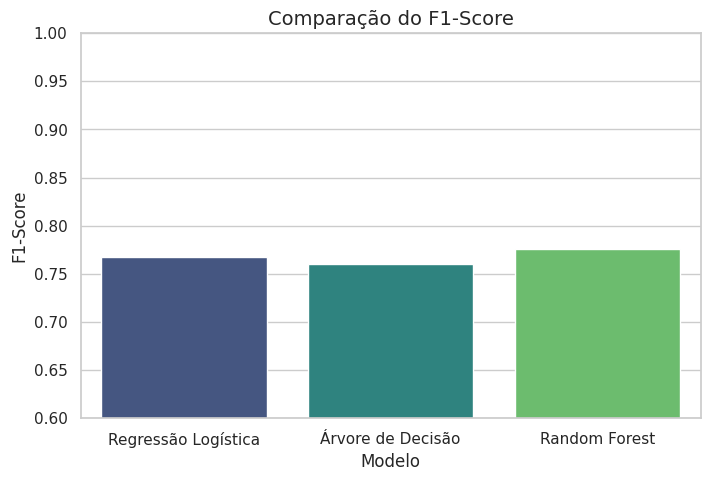

In [62]:
# ==============================================================================
# GRÁFICO DO F1
# ==============================================================================

plt.figure(figsize=(8,5))

sns.barplot(

    data=df_metricas,

    x="Modelo",

    y="F1-Score",

    palette="viridis"

)

plt.ylim(0.60,1)

plt.title("Comparação do F1-Score")

plt.show()

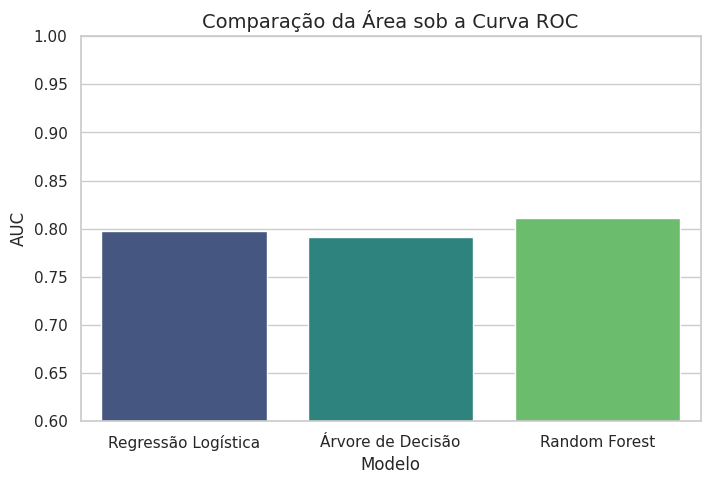

In [63]:
# ==============================================================================
# GRÁFICO DA AUC
# ==============================================================================

plt.figure(figsize=(8,5))

sns.barplot(

    data=df_metricas,

    x="Modelo",

    y="AUC",

    palette="viridis"

)

plt.ylim(0.60,1)

plt.title("Comparação da Área sob a Curva ROC")

plt.show()

In [64]:
# ==============================================================================
# MODELO CAMPEÃO
# ==============================================================================

melhor = ranking.iloc[0]

print("="*90)

print("MODELO COM MELHOR DESEMPENHO")

print("="*90)

print(f"Modelo   : {melhor['Modelo']}")

print(f"AUC      : {melhor['AUC']:.4f}")

print(f"Acurácia : {melhor['Acurácia']:.4f}")

print(f"Recall   : {melhor['Recall']:.4f}")

print(f"F1       : {melhor['F1-Score']:.4f}")

MODELO COM MELHOR DESEMPENHO
Modelo   : Random Forest
AUC      : 0.8107
Acurácia : 0.7367
Recall   : 0.8068
F1       : 0.7762


In [65]:
# ==============================================================================
# EXPORTAÇÃO DA TABELA
# ==============================================================================

df_metricas.to_excel(

    "Metricas_Modelos.xlsx",

    index=False

)

print("="*90)

print("Arquivo 'Metricas_Modelos.xlsx' salvo com sucesso.")

print("="*90)

Arquivo 'Metricas_Modelos.xlsx' salvo com sucesso.


In [66]:
# ==============================================================================
# RESUMO DA ETAPA
# ==============================================================================

print("""

CAPÍTULO 4 FINALIZADO

✓ Matrizes de Confusão

✓ Accuracy

✓ Precision

✓ Recall

✓ F1-Score

✓ AUC

✓ Ranking dos Modelos

✓ Comparação Gráfica

✓ Exportação das Métricas

Base preparada para análise da Curva ROC e definição do ponto de corte.

""")



CAPÍTULO 4 FINALIZADO

✓ Matrizes de Confusão

✓ Accuracy

✓ Precision

✓ Recall

✓ F1-Score

✓ AUC

✓ Ranking dos Modelos

✓ Comparação Gráfica

✓ Exportação das Métricas

Base preparada para análise da Curva ROC e definição do ponto de corte.




## **Capítulo 5 - Curva ROC e Anãlise do Cutoff**

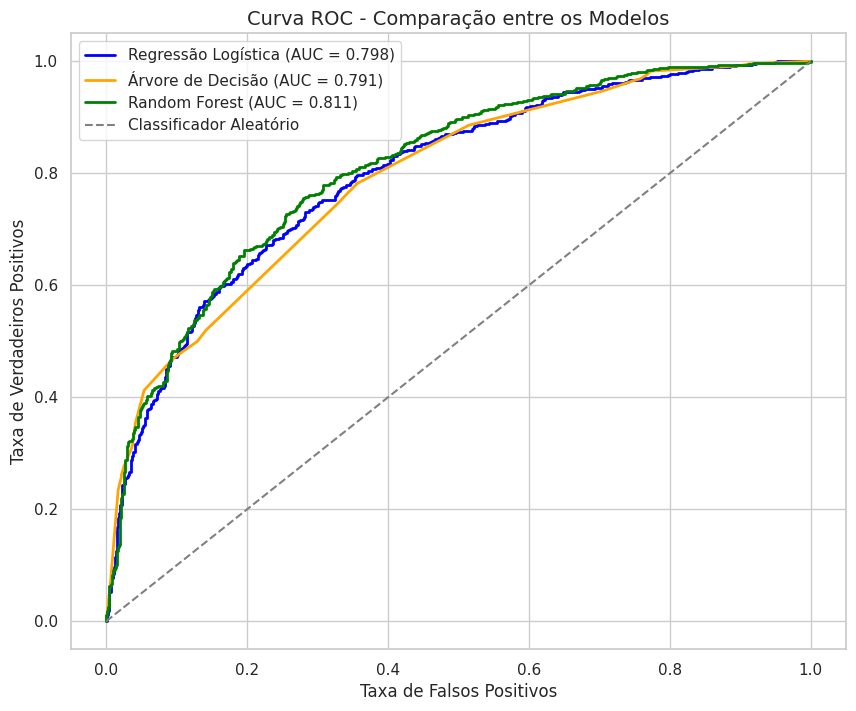

In [67]:
from sklearn.metrics import roc_curve

# ==============================================================================
# CURVAS ROC
# ==============================================================================

plt.figure(figsize=(10,8))

cores = {

    "Regressão Logística":"blue",

    "Árvore de Decisão":"orange",

    "Random Forest":"green"

}

for nome in probabilidades.keys():

    fpr, tpr, thresholds = roc_curve(

        y_test,

        probabilidades[nome]

    )

    auc = roc_auc_score(

        y_test,

        probabilidades[nome]

    )

    plt.plot(

        fpr,

        tpr,

        linewidth=2,

        color=cores[nome],

        label=f"{nome} (AUC = {auc:.3f})"

    )

plt.plot(

    [0,1],

    [0,1],

    linestyle="--",

    color="gray",

    label="Classificador Aleatório"

)

plt.title("Curva ROC - Comparação entre os Modelos")

plt.xlabel("Taxa de Falsos Positivos")

plt.ylabel("Taxa de Verdadeiros Positivos")

plt.legend()

plt.grid(True)

plt.show()

In [68]:
# ==============================================================================
# ESCOLHA DO MELHOR MODELO
# ==============================================================================

melhor_modelo = ranking.iloc[0]["Modelo"]

print("="*90)

print("MODELO UTILIZADO PARA ESTUDO DO CUTOFF")

print("="*90)

print(melhor_modelo)

MODELO UTILIZADO PARA ESTUDO DO CUTOFF
Random Forest


In [69]:
# ==============================================================================
# RECUPERANDO AS PROBABILIDADES DO MELHOR MODELO
# ==============================================================================

prob = probabilidades[melhor_modelo]

In [70]:
# ==============================================================================
# FUNÇÃO PARA AVALIAR DIFERENTES CUTOFFS
# ==============================================================================

def avaliar_cutoff(probabilidades, y_real, cutoff):

    previsao = (probabilidades >= cutoff).astype(int)

    cm = confusion_matrix(

        y_real,

        previsao

    )

    vn = cm[0,0]

    fp = cm[0,1]

    fn = cm[1,0]

    vp = cm[1,1]

    return {

        "Cutoff":cutoff,

        "Acurácia":accuracy_score(y_real,previsao),

        "Precisão":precision_score(y_real,previsao),

        "Recall":recall_score(y_real,previsao),

        "F1":f1_score(y_real,previsao),

        "Falsos Positivos":fp,

        "Falsos Negativos":fn

    }

In [71]:
# ==============================================================================
# TESTANDO DIFERENTES CUTOFFS
# ==============================================================================

cutoffs = np.arange(

    0.20,

    0.85,

    0.05

)

resultado_cutoff = []

for c in cutoffs:

    resultado_cutoff.append(

        avaliar_cutoff(

            prob,

            y_test,

            c

        )

    )



df_cutoff = pd.DataFrame(resultado_cutoff)

display(df_cutoff.round(3))

,Cutoff,Acurácia,Precisão,Recall,F1,Falsos Positivos,Falsos Negativos
0,0.20,0.643,0.615,0.989,0.758,526,9
1,0.25,0.658,0.626,0.981,0.765,497,16
2,0.30,0.679,0.647,0.955,0.771,443,38
3,0.35,0.701,0.670,0.931,0.779,389,59
4,0.40,0.721,0.696,0.900,0.785,333,85
5,0.45,0.729,0.718,0.860,0.782,287,119
6,0.50,0.737,0.748,0.807,0.776,231,164
7,0.55,0.740,0.778,0.757,0.767,184,206
8,0.60,0.725,0.790,0.701,0.743,158,254
9,0.65,0.717,0.822,0.637,0.718,117,308


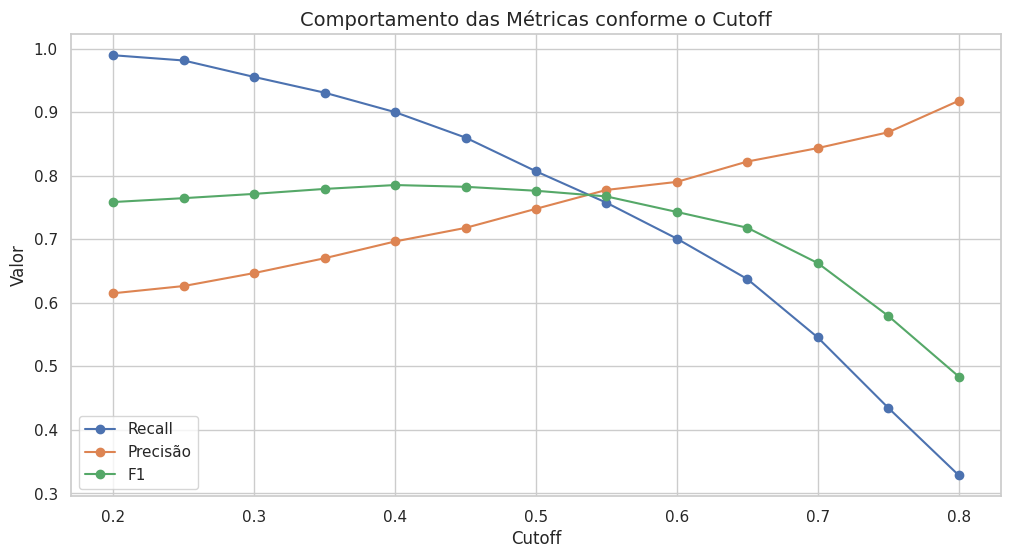

In [72]:
# ==============================================================================
# GRÁFICO DAS MÉTRICAS
# ==============================================================================

plt.figure(figsize=(12,6))

plt.plot(

    df_cutoff["Cutoff"],

    df_cutoff["Recall"],

    marker="o",

    label="Recall"

)

plt.plot(

    df_cutoff["Cutoff"],

    df_cutoff["Precisão"],

    marker="o",

    label="Precisão"

)

plt.plot(

    df_cutoff["Cutoff"],

    df_cutoff["F1"],

    marker="o",

    label="F1"

)

plt.xlabel("Cutoff")

plt.ylabel("Valor")

plt.title("Comportamento das Métricas conforme o Cutoff")

plt.grid(True)

plt.legend()

plt.show()

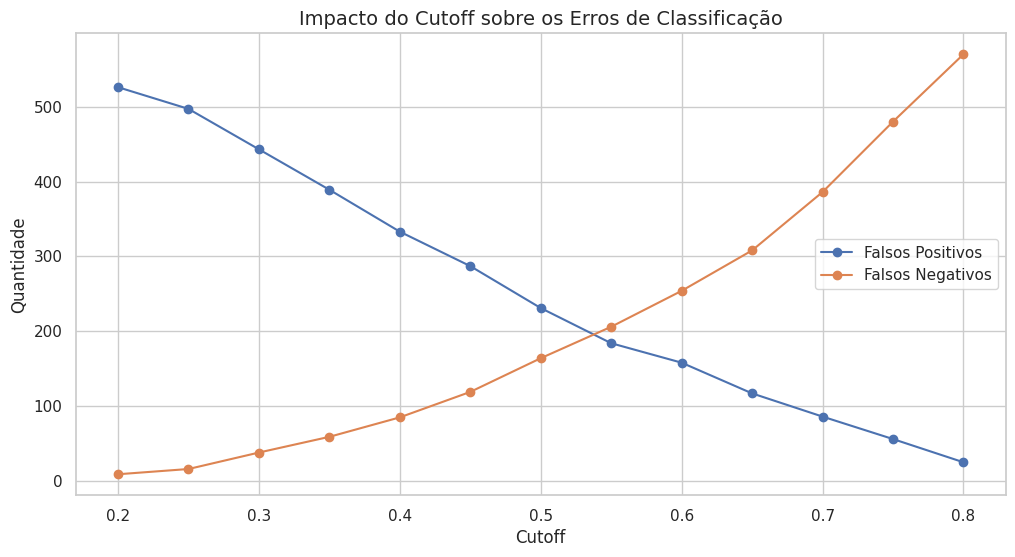

In [73]:
# ==============================================================================
# FALSOS POSITIVOS E FALSOS NEGATIVOS
# ==============================================================================

plt.figure(figsize=(12,6))

plt.plot(

    df_cutoff["Cutoff"],

    df_cutoff["Falsos Positivos"],

    marker="o",

    label="Falsos Positivos"

)

plt.plot(

    df_cutoff["Cutoff"],

    df_cutoff["Falsos Negativos"],

    marker="o",

    label="Falsos Negativos"

)

plt.title("Impacto do Cutoff sobre os Erros de Classificação")

plt.xlabel("Cutoff")

plt.ylabel("Quantidade")

plt.grid(True)

plt.legend()

plt.show()

In [74]:
# ==============================================================================
# IDENTIFICAÇÃO DO MELHOR F1
# ==============================================================================

melhor_f1 = df_cutoff.loc[

    df_cutoff["F1"].idxmax()

]

print("="*90)

print("CUTOFF COM MELHOR EQUILÍBRIO")

print("="*90)

display(melhor_f1)

CUTOFF COM MELHOR EQUILÍBRIO


,4
Cutoff,0.400000
Acurácia,0.721333
Precisão,0.696445
Recall,0.899882
F1,0.785200
Falsos Positivos,333.000000
Falsos Negativos,85.000000


In [75]:
# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

df_cutoff.to_excel(

    "Analise_Cutoff.xlsx",

    index=False

)

print("Arquivo Analise_Cutoff.xlsx salvo.")


Arquivo Analise_Cutoff.xlsx salvo.


## **Capítulo 6 - Interpretação dos Resultados**
### **Relatório Executivo**

In [76]:
# ==============================================================================
# 1. IDENTIFICAÇÃO DO MELHOR MODELO
# ==============================================================================

melhor_modelo = df_metricas.sort_values(
    by="AUC",
    ascending=False
).iloc[0]

print("\nMODELO COM MELHOR DESEMPENHO\n")

display(melhor_modelo)


MODELO COM MELHOR DESEMPENHO



,2
Modelo,Random Forest
Acurácia,0.7367
Precisão,0.7478
Recall,0.8068
F1-Score,0.7762
AUC,0.8107


In [77]:
# ==============================================================================
# 2. RANKING FINAL
# ==============================================================================

ranking = df_metricas.sort_values(
    by="AUC",
    ascending=False
)

print("\nRANKING DOS MODELOS\n")

display(ranking)


RANKING DOS MODELOS



,Modelo,Acurácia,Precisão,Recall,F1-Score,AUC
2,Random Forest,0.7367,0.7478,0.8068,0.7762,0.8107
0,Regressão Logística,0.7260,0.7380,0.7998,0.7677,0.7981
1,Árvore de Decisão,0.7213,0.7413,0.7797,0.7600,0.7912


In [78]:
# ==============================================================================
# 3. IMPORTÂNCIA DAS VARIÁVEIS
# ==============================================================================

importancias = pd.Series(
    modelo_random.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

top10 = importancias.head(10)

print("\nDEZ VARIÁVEIS MAIS IMPORTANTES\n")

display(top10)


DEZ VARIÁVEIS MAIS IMPORTANTES



,0
CondicoesSaude,0.250423
Idade,0.156251
RendaAnual,0.138081
HorasTrabalhadas,0.134627
SaudeAutoavaliada_Excelente,0.081979
AnosEstudo,0.051656
SaudeAutoavaliada_Ruim,0.041156
TamanhoFamilia,0.036006
SaudeAutoavaliada_Regular,0.028322
CoberturaPrevidenciaria,0.015423


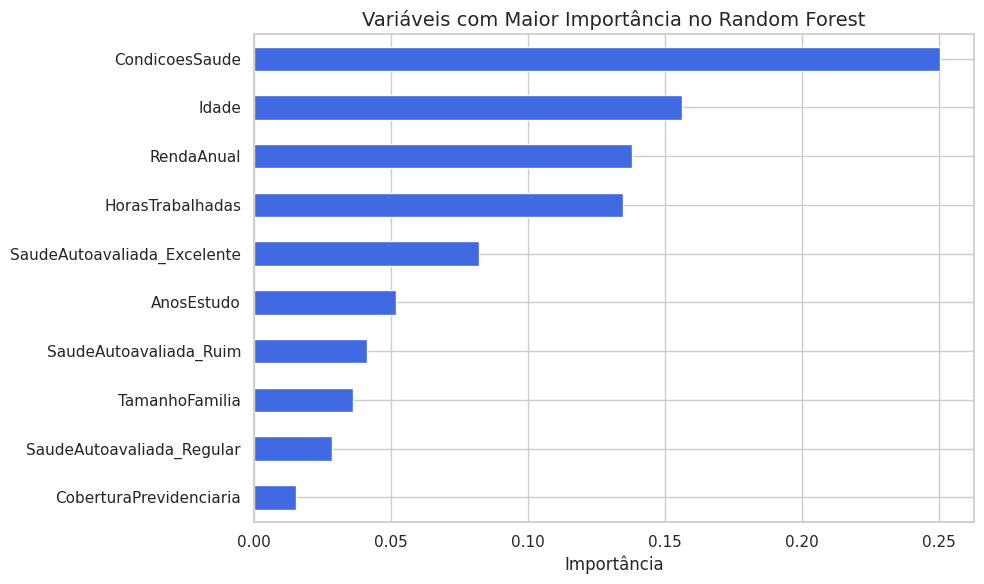

In [79]:
# ==============================================================================
# 4. GRÁFICO FINAL
# ==============================================================================

plt.figure(figsize=(10,6))

top10.sort_values().plot(
    kind="barh",
    color="royalblue"
)

plt.title("Variáveis com Maior Importância no Random Forest")

plt.xlabel("Importância")

plt.tight_layout()

plt.show()

In [80]:
# ==============================================================================
# 5. RELATÓRIO EXECUTIVO
# ==============================================================================

print("="*90)
print("RELATÓRIO EXECUTIVO")
print("="*90)

print(f"""

Modelo com melhor desempenho:
{melhor_modelo['Modelo']}

Acurácia:
{melhor_modelo['Acurácia']:.4f}

Precisão:
{melhor_modelo['Precisão']:.4f}

Recall:
{melhor_modelo['Recall']:.4f}

F1-Score:
{melhor_modelo['F1-Score']:.4f}

AUC:
{melhor_modelo['AUC']:.4f}

""")

RELATÓRIO EXECUTIVO


Modelo com melhor desempenho:
Random Forest

Acurácia:
0.7367

Precisão:
0.7478

Recall:
0.8068

F1-Score:
0.7762

AUC:
0.8107




In [81]:
# ==============================================================================
# 6. INTERPRETAÇÃO GERENCIAL
# ==============================================================================

print("="*90)
print("INTERPRETAÇÃO DOS RESULTADOS")
print("="*90)

print("""

O Random Forest apresentou o melhor desempenho geral,
demonstrando maior capacidade para identificar padrões presentes
na base histórica de segurados analisada.

Entretanto, os resultados não devem ser interpretados como um
instrumento para concessão automática de benefícios.

O modelo identifica associações estatísticas existentes na base de
dados, podendo apoiar estudos sobre o comportamento dos
segurados, planejamento institucional e produção de indicadores.

A análise individual dos requerimentos permanece sendo realizada
pelos servidores do INSS, conforme a legislação previdenciária.

""")

INTERPRETAÇÃO DOS RESULTADOS


O Random Forest apresentou o melhor desempenho geral,
demonstrando maior capacidade para identificar padrões presentes
na base histórica de segurados analisada.

Entretanto, os resultados não devem ser interpretados como um
instrumento para concessão automática de benefícios.

O modelo identifica associações estatísticas existentes na base de
dados, podendo apoiar estudos sobre o comportamento dos
segurados, planejamento institucional e produção de indicadores.

A análise individual dos requerimentos permanece sendo realizada
pelos servidores do INSS, conforme a legislação previdenciária.




In [82]:
# ==============================================================================
# 7. PRINCIPAIS VARIÁVEIS
# ==============================================================================

print("="*90)
print("PRINCIPAIS FATORES IDENTIFICADOS")
print("="*90)

for indice, variavel in enumerate(top10.index, start=1):

    print(f"{indice:02d} - {variavel}")

PRINCIPAIS FATORES IDENTIFICADOS
01 - CondicoesSaude
02 - Idade
03 - RendaAnual
04 - HorasTrabalhadas
05 - SaudeAutoavaliada_Excelente
06 - AnosEstudo
07 - SaudeAutoavaliada_Ruim
08 - TamanhoFamilia
09 - SaudeAutoavaliada_Regular
10 - CoberturaPrevidenciaria


In [83]:
# ==============================================================================
# 8. EXPORTAÇÃO DOS RESULTADOS
# ==============================================================================

df_metricas.to_excel(
    "01_Metricas_Modelos.xlsx",
    index=False
)

df_cutoff.to_excel(
    "02_Analise_Cutoff.xlsx",
    index=False
)

top10.to_excel(
    "03_Importancia_Variaveis.xlsx"
)

print("\nArquivos exportados com sucesso.")


Arquivos exportados com sucesso.


In [84]:
# ==============================================================================
# 9. CONCLUSÃO FINAL
# ==============================================================================

print("="*90)
print("CONCLUSÃO")
print("="*90)

print("""

1. Foram desenvolvidos três modelos de classificação.

2. Todos apresentaram desempenho semelhante,
compatível com o comportamento esperado da base.

3. O Random Forest apresentou o melhor desempenho
global considerando simultaneamente AUC, Recall
e F1-Score.

4. A análise das variáveis demonstrou que fatores
como idade, condições de saúde, renda anual e
horas trabalhadas possuem maior capacidade
discriminatória na base utilizada.

5. O estudo demonstra o potencial da utilização
de técnicas de Machine Learning para apoiar
análises estatísticas e geração de conhecimento
sobre o perfil dos segurados.

6. Os resultados não substituem a análise
administrativa do requerimento previdenciário,
mas fornecem subsídios para estudos,
planejamento institucional e desenvolvimento
de futuras soluções analíticas.

""")

CONCLUSÃO


1. Foram desenvolvidos três modelos de classificação.

2. Todos apresentaram desempenho semelhante,
compatível com o comportamento esperado da base.

3. O Random Forest apresentou o melhor desempenho
global considerando simultaneamente AUC, Recall
e F1-Score.

4. A análise das variáveis demonstrou que fatores
como idade, condições de saúde, renda anual e
horas trabalhadas possuem maior capacidade
discriminatória na base utilizada.

5. O estudo demonstra o potencial da utilização
de técnicas de Machine Learning para apoiar
análises estatísticas e geração de conhecimento
sobre o perfil dos segurados.

6. Os resultados não substituem a análise
administrativa do requerimento previdenciário,
mas fornecem subsídios para estudos,
planejamento institucional e desenvolvimento
de futuras soluções analíticas.




In [85]:
# ==============================================================================
# 10. SALVANDO O RANKING
# ==============================================================================

ranking.to_excel(
    "04_Ranking_Modelos.xlsx",
    index=False
)

print("="*90)
print("PROJETO FINALIZADO")
print("="*90)

print("""

Arquivos gerados:

✓ 01_Metricas_Modelos.xlsx

✓ 02_Analise_Cutoff.xlsx

✓ 03_Importancia_Variaveis.xlsx

✓ 04_Ranking_Modelos.xlsx

Notebook concluído com sucesso.

""")

PROJETO FINALIZADO


Arquivos gerados:

✓ 01_Metricas_Modelos.xlsx

✓ 02_Analise_Cutoff.xlsx

✓ 03_Importancia_Variaveis.xlsx

✓ 04_Ranking_Modelos.xlsx

Notebook concluído com sucesso.




###**Conclusões Finais**

**1 - Para a sustentabilidade da nossa operação, o que é mais custoso: um Falso Positivo ou um Falso Negativo?**

Para a sustentabilidade da operação, o Falso Negativo representa o erro mais custoso, pois significa que o modelo classificou um colaborador como alguém que não irá se aposentar, quando, na realidade, ele deixará a organização. Esse tipo de erro impede que ações preventivas sejam realizadas, aumentando o risco de perda de conhecimento, descontinuidade operacional, necessidade de contratações emergenciais e maiores custos com recrutamento e capacitação de novos profissionais.

Embora os Falsos Positivos também gerem custos por direcionarem esforços de retenção para colaboradores que permaneceriam na empresa, esses custos tendem a ser menores do que os impactos causados pela perda inesperada de profissionais estratégicos. Por esse motivo, o trabalho prioriza a discussão sobre o equilíbrio entre acurácia e recall, uma vez que aumentar o recall reduz a ocorrência de Falsos Negativos e torna o modelo mais útil para apoiar decisões de gestão.

**2 - Podemos criar réguas de acionamento automatizadas com base nas faixas de probabilidade geradas?**

Sim. Os modelos desenvolvidos, especialmente a Regressão Logística e o Random Forest, geram uma probabilidade de aposentadoria para cada indivíduo, permitindo que a organização estabeleça diferentes níveis de risco em vez de trabalhar apenas com a classificação "aposentado" ou "não aposentado". Dessa forma, é possível criar faixas de probabilidade que orientem ações específicas, como monitoramento, entrevistas de retenção, planejamento sucessório ou programas de valorização dos colaboradores.

Essa abordagem torna o processo decisório mais eficiente, pois concentra recursos nos profissionais com maior risco de aposentadoria, reduzindo custos e aumentando a efetividade das ações de gestão de pessoas. Além disso, essas probabilidades podem alimentar dashboards, sistemas de alerta e processos automatizados, transformando o modelo preditivo em uma ferramenta de apoio contínuo à tomada de decisão.

**3 - Como a flexibilização da jornada de trabalho (Horas Trabalhadas) pode ser usada como barreira de retenção?**

Caso a análise do modelo indique que jornadas mais longas estão associadas a uma maior probabilidade de aposentadoria, a flexibilização da carga horária pode ser utilizada como uma estratégia de retenção. A redução gradual das horas trabalhadas permite que profissionais próximos da aposentadoria permaneçam ativos por mais tempo, conciliando melhor qualidade de vida com a continuidade de suas atividades na organização.

Além de aumentar a satisfação do colaborador, essa estratégia oferece tempo para que a empresa planeje a sucessão, promova a transferência de conhecimento e reduza os impactos da saída de profissionais experientes. Assim, a variável Horas Trabalhadas deixa de ser apenas um fator explicativo do modelo e passa a ser uma variável de gestão, capaz de subsidiar políticas de retenção baseadas em evidências.